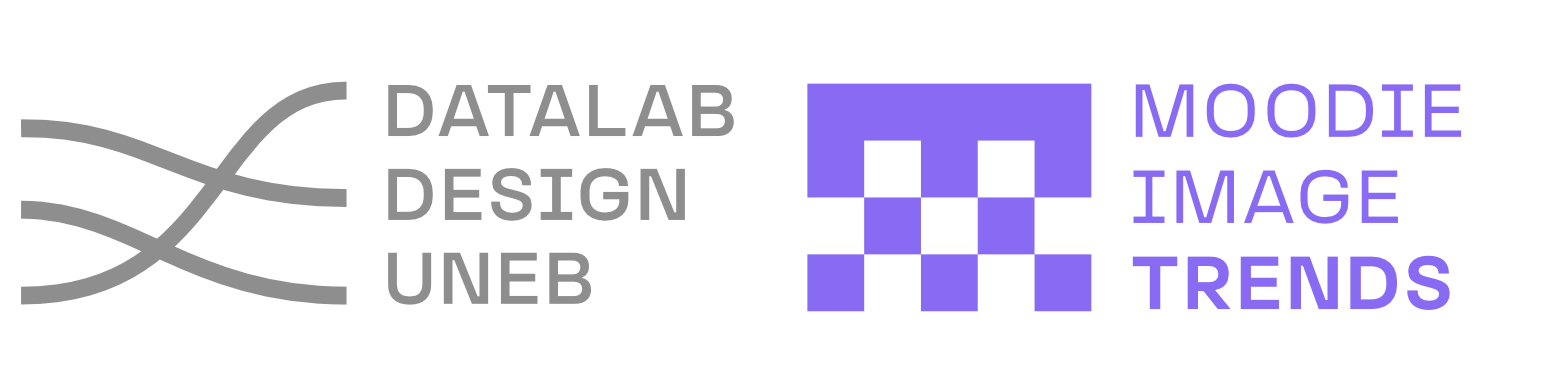

desenvolvido por [Elias Bitencourt](https://eliasbitencourt.com) | [Datalab Design](https://datalabdesign.org) - UNEB BAHIA BRASIL

#MOODIE Image Trends  ·  Múdulo de análise de tendências

MOODIE Trends é o módulo para exploração de padrões cromáticos e análise de tendências do [`MOODIE IMAGE DESIGN`](https://github.com/datalabdesign/moodie), Desenvolvido para permitir a experimentação com ferramentas de visão computacional e algoritmos de recomendação customizáveis aplicadas a etapas de projetos em design ou como ponto de partida para pesquisas com visualidades. Ele está em fase beta, sendo o primeiro módulo funcional da ferramenta MOODIE.

* *Para detalhes sobre a licença de uso veja [`LICENSE.txt`](https://github.com/datalabdesign/moodie/blob/main/LICENCE.txt).*

* **Como citar (formato APA):** Bitencourt, E. (2025). *MOODIE: Modular Observational & Operational Design Image Explorer* (Versão beta) [Repositório GitHub]. Datalab/Design – Universidade do Estado da Bahia. https://github.com/datalabdesign/moodie



In [ ]:
# @title #01 Instalando as dependências para o MOODIE
import ipywidgets as widgets
from IPython.display import display, clear_output
import subprocess, sys, importlib.util, time, base64
import time
from io import BytesIO
from PIL import Image
import re
import pandas as pd



LOGO_BASE64 = """
...
"""

try:
    _logo_bytes = base64.b64decode(LOGO_BASE64) if LOGO_BASE64.strip() else None
    GLOBAL_LOGO = Image.open(BytesIO(_logo_bytes)).convert("RGBA") if _logo_bytes else None
except Exception:
    GLOBAL_LOGO = None  # evita quebra se a string estiver vazia/inválida

#_logo_bytes = base64.b64decode(LOGO_BASE64)
#GLOBAL_LOGO = Image.open(BytesIO(_logo_bytes)).convert("RGBA")

def _already_installed(pkg: str) -> bool:
    """Retorna True se o pacote já estiver presente no ambiente."""
    return importlib.util.find_spec(pkg) is not None

# FUnção auxiliar.. garante que teremos diretório mesmo se o usuário pular o modulo do diretório
def ensure_project_dir():
    """
    Garante que:
      • project_dir exista com todas as subpastas-padrão;
      • project_name esteja definido (fallback: 'moodie_temp').
    """
    global project_dir, project_name

    # Cria project_dir se não existir
    if 'project_dir' not in globals():
        project_dir = os.path.join(os.getcwd(), 'MOODIE_temp')
        print(f"[MOODIE] 'project_dir' não estava definido; usando {project_dir}")

    # Cria subpastas padrão
    for sd in ["datasets", "reports", "imagens", "imagewall", "paleta"]:
        os.makedirs(os.path.join(project_dir, sd), exist_ok=True)

    # Garante project_name
    if 'project_name' not in globals() or not project_name:
        project_name = "moodie_temp"





#   Função geral para detectar colunas que guardam nomes de
#   arquivos de imagem... para evitar que usuário selecione coluna errada e quebre o codigo

_IMG_PAT = re.compile(
    r'^[^/\\<>:"|?*]+\.(?:jpe?g|png|gif|tiff?|bmp|webp)$',  # sem barra, só nome.ext
    re.I
)

def detect_image_columns(df: pd.DataFrame,
                         min_match_ratio: float = 0.90,
                         sample_size: int = 250) -> list[str]:
    """
    Devolve apenas as colunas cujo **conteúdo é majoritariamente
    nomes de arquivos de imagem** (sem URLs, tags HTML etc.).

    • min_match_ratio ... fração mínima de matches (ex.: 0.9 = 90 %)
    • sample_size ....... nº máx. de amostras inspecionadas por coluna
    """
    if df is None or df.empty:
        return []

    good_cols = []
    for col in df.columns:
        if not pd.api.types.is_string_dtype(df[col]):
            continue

        sample = df[col].dropna().astype(str).head(sample_size)
        if sample.empty or sample.nunique() < 1:       # precisa ter diversidade
            continue

        bad_hint = sample.str.contains(r'[/\\]|http|<|>', case=False, regex=True)
        if bad_hint.any():
            continue                                   # já descarta

        ok_ratio = sample.str.match(_IMG_PAT).mean()
        if ok_ratio >= min_match_ratio:
            good_cols.append(col)

    return good_cols



def install_dependencies(button):
    with output:
        clear_output()
        progress_bar = widgets.IntProgress(value=0, min=0, max=7, description="Instalando...")
        display(progress_bar)
        print("Instalando tudo que você precisa para usar o MOODIE... Espera só um pouquinho.")

        # Cada pacote é informado em uma posição da lista
        dependencies = [
            "imagehash",
            "colorthief",
            "pillow",
            "umap-learn",
            "hdbscan",
            "distinctipy",
            "bokeh"
        ]

        for i, dependency in enumerate(dependencies):
            try:
                subprocess.check_call(["pip", "install", dependency], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
                progress_bar.value = i + 1
                time.sleep(1)  # Simula o tempo de instalação
            except subprocess.CalledProcessError as e:
                clear_output()
                print(f"Erro ao instalar {dependency}. Tentando novamente...")
                try:
                    subprocess.check_call(["pip", "install", "--no-cache-dir", dependency], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
                    progress_bar.value = i + 1
                    time.sleep(1)
                except subprocess.CalledProcessError as e:
                    clear_output()
                    print(f"Erro ao instalar {dependency}.")
                    print("Verifique sua conexão ou tente novamente mais tarde.")
                    return
                time.sleep(0.1)  # feedback visua

        clear_output()
        print("Instalação concluída com sucesso!")

install_button = widgets.Button(description="Instalar")
output = widgets.Output()

install_button.on_click(install_dependencies)

display(install_button, output)


In [ ]:
# @title #02 Conectando ao Google Drive
#@markdown O MOODIE funciona melhor se você estiver conectado ao seu google drive.
#@markdown Isso evita que arquivos muito pesados tornem o processo ainda mais lento.
#@markdown Mas, se você preferir trabalhar com os arquivos fazendo upload, também é uma opção.
#@markdown É só seguir para o módulo 03.

import os
import ipywidgets as widgets
from IPython.display import display, clear_output

# Seção 1: Conexão com Google Drive
# Flag global para indicar se o Drive foi conectado
drive_connected = False # garante existência da flag mesmo se bloco #02 não for executado

# Área de saída para a conexão
connect_output = widgets.Output()

def on_connect_clicked(b):
    global drive_connected
    with connect_output:
        clear_output()
        if importlib.util.find_spec("google.colab") is None:
            print("Este notebook não está rodando no Google Colab. Pule esta etapa.")
            return
        try:
            from google.colab import drive
            drive.mount('/content/drive')
            drive_connected = True
            print("Google Drive conectado com sucesso.")
            # Atualiza o botão para indicar que a conexão foi realizada
            connect_button.description = "Google Drive Conectado"
            connect_button.disabled = True
        except Exception as e:
            print("Erro ao conectar o Google Drive:", e)

# Botão para conectar ao Google Drive
connect_button = widgets.Button(
    description="Conectar ao Google Drive",
    layout=widgets.Layout(width='300px')
)
connect_button.on_click(on_connect_clicked)

# Exibe a interface de conexão
display(widgets.VBox([connect_button, connect_output]))

In [ ]:
# @title #03 Criando diretórios de trabalho
#@markdown Agora vamos começar a organizar nosso ambiente de trabalho!
#@markdown 1. Se você já se conectou ao google drive, Marque SIM. Se prefere trabalhar fazendo uploads, marque NÃO.
#@markdown 2. Se você já tem uma pasta no seu drive ou no amnbiente do google colab, marque a opção "Diretório Existente". Mas se quiser começar um novo projeto, marque "Novo Diretório"
#@markdown 3. Se você marcou "Novo diretório", basta informar o nome da pasta onde você quer salvar os trabalhos e indicar o caminho dessa pasta.
#@markdown    - Se você está conectado ao google drive, cole o caminho da sua pasta. Você pode visualizar o caminho abrindo o menu lateral à sua esquerda selecionando o ícone da pasta (files), depois procurando pela pasta Drive. No menu dropdown dessa pasta vc verá a árvore dos seus arquivos no google drive. Basta procurar o diretório desejado, clicar com o botão direito do mouse e selecionar "copiar path".
#@markdown    - Se você deseja usar algum diretório que já está no seu ambiente colab, o processo é o mesmo. Basta procurar pela sua pasta na lateral esquerda e repetir o processo.
#@markdown    - Se optar por deixar esse campo em branco, o MOODIE vai criar uma pasta com o nome desejado no seu drive, se estiver conectado, ou no ambiente do colab.

#@markdown 4. Agora digite o nome do seu projeto. Ele será usado para customizar os nomes dos arquivos que o MOODIE vai salvar pra você.
#@markdown 5. Escreva uma nota mental sobre o que é o seu projeto e outra informação que você achar importante. O MOODIE vai salvar um arquivo de registro com todas as informações organizadas para facilitar a sua navegação posterior
# Widget que pergunta se você está conectado ao Google Drive.
# Caso o botão de conexão tenha sido clicado, o padrão será "Sim".

if 'drive_connected' not in globals():
    drive_connected = False


#widgets interface

default_connected = 'Sim' if drive_connected else 'Não'
connection_status = widgets.RadioButtons(
    options=['Sim', 'Não'],
    value=default_connected,
    description='Está conectado ao Google Drive?',
    layout=widgets.Layout(width='600px'),
    style={'description_width': '220px'}
)

# Widget para escolha entre criar um novo diretório ou usar um existente.
directory_choice = widgets.RadioButtons(
    options=['Novo diretório', 'Diretório existente'],
    value='Novo diretório',
    description='Opção:',
    layout=widgets.Layout(width='600px'),
    style={'description_width': '150px'}
)

# Widgets para quando for criar um novo diretório.
folder_input = widgets.Text(
    value='',
    placeholder='Digite o nome da nova pasta',
    description='Nome da Pasta:',
    layout=widgets.Layout(width='600px'),
    style={'description_width': '150px'}
)

specific_path_input = widgets.Text(
    value='',
    placeholder='Opcional: caminho específico onde criar a pasta',
    description='Caminho específico:',
    layout=widgets.Layout(width='600px'),
    style={'description_width': '150px'}
)

# Widget para quando for utilizar um diretório existente.
existing_folder_input = widgets.Text(
    value='',
    placeholder='Digite o caminho do diretório existente',
    description='Diretório existente:',
    layout=widgets.Layout(width='600px'),
    style={'description_width': '150px'}
)

# Widgets para os dados do projeto.
project_name_input = widgets.Text(
    value='',
    placeholder='Digite o nome do projeto',
    description='Nome do Projeto:',
    layout=widgets.Layout(width='600px'),
    style={'description_width': '150px'}
)

project_description_input = widgets.Textarea(
    value='',
    placeholder='Digite uma breve descrição do projeto',
    description='Descrição do Projeto:',
    layout=widgets.Layout(width='600px', height='150px'),
    style={'description_width': '150px'}
)

# Botão para confirmar as escolhas.
confirm_button = widgets.Button(
    description='Confirmar'
)

# Área de saída para exibir mensagens da criação dos diretórios.
dir_output = widgets.Output()

# Atualiza os campos exibidos conforme a escolha entre novo diretório ou diretório existente.
def update_directory_fields(change):
    if change['new'] == 'Novo diretório':
        folder_input.layout.display = ''
        specific_path_input.layout.display = ''
        existing_folder_input.layout.display = 'none'
    else:
        folder_input.layout.display = 'none'
        specific_path_input.layout.display = 'none'
        existing_folder_input.layout.display = ''

directory_choice.observe(update_directory_fields, names='value')
update_directory_fields({'new': directory_choice.value})

# Função que processa as informações e cria (ou utiliza) o diretório com a estrutura do projeto.
def on_confirm_clicked(b):
    global project_name, project_dir  # Variáveis globais para uso posterior na pipeline
    with dir_output:
        clear_output()
        # Define o caminho base dependendo da opção selecionada na segunda interface.
        if connection_status.value == 'Sim':
            base_path = '/content/drive/My Drive'
        else:
            base_path = '/content'

        # Seleciona o diretório do projeto conforme a escolha do usuário.
        if directory_choice.value == 'Novo diretório':
            folder_name = folder_input.value.strip()
            if folder_name == '':
                print("Por favor, informe o nome da nova pasta.")
                return
            specific_path = specific_path_input.value.strip()
            if specific_path:
                if not specific_path.startswith('/'):
                    specific_path = os.path.join(base_path, specific_path)
                new_base = specific_path
            else:
                new_base = base_path
            project_folder = os.path.join(new_base, folder_name)
            if not os.path.exists(project_folder):
                os.makedirs(project_folder)
                print(f"Pasta principal criada: {project_folder}")
            else:
                print(f"Pasta principal já existe: {project_folder}")
        else:  # Caso utilize diretório existente.
            project_folder = existing_folder_input.value.strip()
            if project_folder == '':
                print("Por favor, informe o caminho do diretório existente.")
                return
            if not os.path.exists(project_folder):
                print(f"O diretório especificado não existe: {project_folder}")
                return
            print(f"Utilizando diretório existente: {project_folder}")

        # Coleta os dados do projeto.
        project_name = project_name_input.value.strip()
        project_description = project_description_input.value.strip()

        # Cria os subdiretórios necessários.
        subdirs = {
            "datasets": "Local onde os datasets em csv serão salvos",
            "reports": "Local onde os relatórios e documentações dos processamentos serão salvos",
            "imagens": "Local onde as imagens baixadas ficam armazenadas",
            "imagewall": "Local onde as visualizações de dados das imagewals ficam armazenadas",
            "paleta": "Local onde as paletas de cores extraídas do dataset serão salvas",
            #"clusters": "Local onde os arquivos e visualizações dos clusters são armazenados"
        }

        for subdir in subdirs.keys():
            path_subdir = os.path.join(project_folder, subdir)
            if not os.path.exists(path_subdir):
                os.makedirs(path_subdir)

        # Monta a estrutura do projeto em formato de string.
        tree_str = (
            f"Nome do Projeto: {project_name}\n\n"
            f"Descrição do Projeto: {project_description}\n\n"
            f"Estrutura da árvore de arquivos:\n\n"
            f"{project_folder}\n"
        )
        for subdir, desc in subdirs.items():
            tree_str += f"├── {subdir}  ---> {desc}\n"
        tree_str += "\nOBS: no módulo das imagewals é possível gerar paleta de cores por clusters.\n"
        tree_str += "As imagens serão salvas dentro de subdiretórios da pasta imagewall.\n\n"
        tree_str += ("OBS 2: para facilitar a diferenciação e documentação do processo, "
                     "os arquivos importantes são salvos com registro de tempo ao final no formato "
                     "DD_MM_AA_HH_MM (Dia_Mês_Ano_Hora_Minuto).\n")

        print(tree_str)

        # Salva um arquivo README com a estrutura do projeto.
        readme_path = os.path.join(project_folder, f"Readme_first_{project_name}.txt")
        try:
            with open(readme_path, "w") as f:
                f.write(tree_str)
            print(f"Readme salvo em: {readme_path}")
        except Exception as e:
            print("Erro ao salvar o Readme:", e)

        project_dir = project_folder
        print("Este diretório será utilizado para salvar os arquivos do projeto.")

confirm_button.on_click(on_confirm_clicked)

# Exibe a segunda interface
display(widgets.VBox([
    connection_status,
    directory_choice,
    folder_input,
    specific_path_input,
    existing_folder_input,
    project_name_input,
    project_description_input,
    confirm_button,
    dir_output
]))


In [ ]:
# @title #04 Descompactar imagens
# @markdown * Este módulo extrai todas as imagens de qualquer estrutura de ZIP,
#   lida com subpastas internas e converte formatos não-JPEG/PNG para JPG.
#   Ao final, informa quantas imagens foram extraídas e quantas foram convertidas.

import os
import shutil
import zipfile
import time  # Para simular progresso
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
from io import BytesIO



# Função de extração do ZIP
def extract_zip_modified(input_zip, progress):
    # Define a pasta de extração dentro de project_dir (ou usa './images/')
    try:
        extraction_folder = os.path.join(project_dir, "imagens")
    except NameError:
        extraction_folder = './images/'
        print("Aviso: 'project_dir' não definido. Usando './images/' como diretório de extração.")

    # Limpa e recria o diretório de imagens
    if os.path.exists(extraction_folder):
        shutil.rmtree(extraction_folder)
    os.makedirs(extraction_folder, exist_ok=True)

    # Abre o ZIP e lista todos os arquivos não-diretório, ignorando __MACOSX
    with zipfile.ZipFile(input_zip, 'r') as zip_ref:
        members = [m for m in zip_ref.namelist() if not m.endswith('/') and not m.startswith('__MACOSX')]
        total = len(members)
        converted_count = 0
        extracted_count = 0

        for idx, member in enumerate(members, start=1):
            progress.value = idx / total
            try:
                data = zip_ref.read(member)
                img = Image.open(BytesIO(data))
            except Exception:
                # Não é imagem válida
                continue

            # Normaliza modo de cor
            if img.mode not in ('RGB', 'RGBA'):
                img = img.convert('RGB')

            # Define extensão de saída
            #fmt = img.format.lower() if hasattr(img, 'format') else ''
            fmt = (img.format or '').lower()
            if fmt in ('jpeg', 'jpg'):
                out_ext = '.jpg'
            elif fmt == 'png':
                out_ext = '.png'
            else:
                out_ext = '.jpg'  # converte outros formatos para JPG
                converted_count += 1

            # Nome de saída: ignora subpastas dentro do ZIP
            base = os.path.basename(member)
            name_no_ext = os.path.splitext(base)[0]
            out_name = name_no_ext + out_ext
            out_path = os.path.join(extraction_folder, out_name)

            # Se PNG e tiver alpha, mantém; se JPG, garante RGB
            if out_ext == '.jpg' and img.mode == 'RGBA':
                img = img.convert('RGB')

            # Salva a imagem convertida ou não
            img.save(out_path)
            extracted_count += 1

    # Garante que o progresso seja 100%
    progress.value = 1.0
    time.sleep(0.1)
    clear_output(wait=True)

    # Feedback ao usuário
    print(f"Foram extraídas {extracted_count} imagens para '{extraction_folder}'.")
    if converted_count:
        print(f"Dessas, {converted_count} foram convertidas para JPG.")

    # Retorna lista de caminhos completos das imagens extraídas
    all_images = [os.path.join(extraction_folder, f)
                  for f in os.listdir(extraction_folder)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    return all_images

# Widgets para escolha da fonte das imagens
images_source_method = widgets.RadioButtons(
    options=['Pasta existente', 'Descompactar ZIP'],
    value='Pasta existente',
    description='Fonte das Imagens:',
    layout=widgets.Layout(width='300px'),
    style={'description_width': '150px'}
)


# Widgets para a opção "Pasta existente"
existing_images_folder_input = widgets.Text(
    value='',
    placeholder='Digite o caminho da pasta com as imagens',
    description='Pasta com Imagens:',
    layout=widgets.Layout(width='80%'),
    style={'description_width': '150px'}
)

process_existing_images_button = widgets.Button(
    description='Processar Imagens',
    button_style='info',
    tooltip='Clique para processar a pasta com imagens'
)

copy_progress = widgets.FloatProgress(
    value=0.0, min=0.0, max=1.0,
    description='Copiando Imagens:',
    layout=widgets.Layout(width='80%')
)
copy_progress.layout.display = 'none'  # Inicia oculto

output_existing = widgets.Output()

# Função para processar a opção de "Pasta existente"
def on_process_existing_images_button_click(b):
    with output_existing:
        clear_output()
        ensure_project_dir()  # garante estrutura completa
        folder_path = existing_images_folder_input.value.strip()
        if not os.path.isdir(folder_path):
            print("O caminho fornecido não é um diretório ou não existe.")
            return

        # Define a pasta de destino para as imagens (dentro do diretório do projeto)
        dest_folder = os.path.join(project_dir, "imagens")
        if not os.path.exists(dest_folder):
            os.makedirs(dest_folder)

        # Se o caminho fornecido for o mesmo da pasta de imagens do projeto, nada a copiar
        if os.path.abspath(folder_path) == os.path.abspath(dest_folder):
            print("As imagens já estão na pasta correta.")
            total_imagens = 0
            for root, dirs, files in os.walk(dest_folder):
                for f in files:
                    if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                        total_imagens += 1
            print(f"Foram encontradas {total_imagens} imagens.")
            return

        # Busca os arquivos de imagem na pasta fornecida
        image_files = []
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_files.append(os.path.join(root, file))
        if not image_files:
            print("Nenhuma imagem encontrada no diretório fornecido.")
            return

        # Copia os arquivos para a pasta de destino com barra de progresso
        print(f"Iniciando cópia de {len(image_files)} imagens...")
        copy_progress.value = 0.0
        copy_progress.layout.display = ''
        total = len(image_files)
        for i, file in enumerate(image_files):
            try:
                shutil.copy2(file, dest_folder)
            except Exception as e:
                print(f"Erro ao copiar {file}: {e}")
            copy_progress.value = (i + 1) / total
            time.sleep(0.01)  # Pequena pausa para simulação visual
        copy_progress.layout.display = 'none'
        print(f"Processo finalizado: {len(image_files)} imagens copiadas para a pasta {dest_folder}.")

process_existing_images_button.on_click(on_process_existing_images_button_click)

existing_images_box = widgets.VBox([
    existing_images_folder_input,
    process_existing_images_button,
    copy_progress,
    output_existing
])


# Widgets para a opção "Descompactar ZIP"
zip_method = widgets.RadioButtons(
    options=['Caminho', 'Upload'],
    value='Caminho',
    description='Método ZIP:',
    layout=widgets.Layout(width='300px'),
    style={'description_width': '100px'}
)

zip_path_widget = widgets.Text(
    description='ZIP Path:',
    placeholder='Digite o caminho do arquivo ZIP',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='80%')
)

zip_upload_widget = widgets.FileUpload(
    accept='.zip',
    multiple=False,
    description="Fazer Upload do ZIP"
)

# Barra de progresso para simulação do upload
upload_progress = widgets.FloatProgress(
    value=0.0, min=0.0, max=1.0,
    description='Upload:',
    layout=widgets.Layout(width='80%')
)
upload_progress.layout.display = 'none'

# Função para atualizar visibilidade dos widgets de entrada do ZIP conforme o método escolhido
def update_zip_input_method(change):
    if change['new'] == 'Caminho':
        zip_path_widget.layout.display = ''         # Exibe o campo de caminho
        zip_upload_widget.layout.display = 'none'     # Oculta o upload
    else:
        zip_path_widget.layout.display = 'none'
        zip_upload_widget.layout.display = ''

zip_method.observe(update_zip_input_method, names='value')
update_zip_input_method({'new': zip_method.value})

# Área de saída para feedback do processo de ZIP
output_zip = widgets.Output()

# Botão para iniciar a extração do ZIP
extract_button = widgets.Button(
    description='Extrair Imagens',
    button_style='info',
    tooltip='Clique para extrair as imagens do arquivo ZIP'
)

def on_extract_button_click_modified(b):
    with output_zip:
        clear_output()
        ensure_project_dir()  # garante estrutura completa

        # fonte ZIP
        if zip_method.value == 'Caminho':
            zip_path = zip_path_widget.value.strip()
            if not os.path.isfile(zip_path):
                print("Arquivo ZIP não encontrado no caminho fornecido.")
                return
            file_to_extract = zip_path

        else:  # Método "Upload"
            if not zip_upload_widget.value:
                print("Por favor, faça upload de um arquivo ZIP.")
                return
            uploaded_filename = list(zip_upload_widget.value.keys())[0]
            content = zip_upload_widget.value[uploaded_filename]['content']
            file_to_extract = os.path.join(os.getcwd(), "uploaded_zip.zip")
            with open(file_to_extract, "wb") as f:
                f.write(content)
            # Feedback do upload
            upload_progress.value = 0.0
            upload_progress.layout.display = ''
            for i in range(0, 101, 10):
                upload_progress.value = i / 100.0
                time.sleep(0.05)
            upload_progress.value = 1.0
            upload_progress.layout.display = 'none'


        # Diretório corrente para possíveis usos futuros
        global current_directory
        current_directory = os.path.dirname(file_to_extract)

        # Barra de progresso da extração
        progress = widgets.FloatProgress(
            value=0.0, min=0.0, max=1.0,
            description='Extraindo:',
            layout=widgets.Layout(width='80%')
        )
        display(progress)

        # Executa a extração
        global extracted_images_paths
        extracted_images_paths = extract_zip_modified(file_to_extract, progress)

        clear_output(wait=True)
        print(f"Foram extraídas {len(extracted_images_paths)} imagens do arquivo {file_to_extract}.")
        print(f"As imagens foram salvas em {os.path.join(project_dir, 'imagens')}.")

# (re)liga o botão
extract_button.on_click(on_extract_button_click_modified)


zip_images_box = widgets.VBox([
    zip_method,
    zip_path_widget,
    zip_upload_widget,
    upload_progress,
    extract_button,
    output_zip
])


# Função para atualizar a interface conforme a opção de fonte de imagens selecionada
def update_images_source_ui(change):
    if change['new'] == 'Pasta existente':
        existing_images_box.layout.display = ''
        zip_images_box.layout.display = 'none'
    else:
        existing_images_box.layout.display = 'none'
        zip_images_box.layout.display = ''

images_source_method.observe(update_images_source_ui, names='value')
# Chama a função de atualização para a configuração inicial
update_images_source_ui({'new': images_source_method.value})


# Exibe a interface completa para o módulo de imagens
display(widgets.VBox([
    images_source_method,
    existing_images_box,
    zip_images_box
]))


In [ ]:
# @title #05 UPLOAD E ANÁLISE DO CSV (Opcional)

# @markdown - Se você já possui uma base de dados em CSV com uma coluna contendo o nome das imagens fornecidas, basta fornecer o arquivo ou o caminho para que MOODIE conecte as coisas.

# @markdown - Mas se você possui apenas as imagens no momento, não se preocupe. É só pular essa etapa que o MOODIE cudará do resto mais à frente.
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
import pandas as pd
import time  # Já estava aqui, ok
import io    # Adicione esta linha

# Função para retornar um timestamp no formato DD_MM_YY_HH_MM
def get_timestamp():
    return time.strftime("%d_%m_%y_%H_%M")

# Interface para escolha do método
# Radio button para selecionar o método de entrada
method_choice = widgets.RadioButtons(
    options=['Upload', 'Fornecer caminho'],
    value='Upload',
    description='Método:',
    layout=widgets.Layout(width='80%'),
    style={'description_width': 'initial'}
)

# Widget para upload do arquivo CSV (aparece se "Upload" for selecionado)
upload_widget = widgets.FileUpload(
    accept='.csv',
    multiple=False,
    layout=widgets.Layout(width='11.5%')
)

# Widget para que o usuário informe o caminho do arquivo CSV (aparece se "Fornecer caminho" for selecionado)
file_path_input = widgets.Text(
    value='',
    placeholder='Forneça o caminho completo para o arquivo CSV',
    description='Caminho do CSV:',
    layout=widgets.Layout(width='80%'),
    style={'description_width': 'initial'}
)
# Inicialmente, esconde o campo de caminho, pois o padrão é "Upload"
file_path_input.layout.display = 'none'

# Função para atualizar os widgets exibidos conforme o método escolhido
def update_method_fields(change):
    if change['new'] == 'Upload':
        upload_widget.layout.display = ''
        file_path_input.layout.display = 'none'
    else:
        upload_widget.layout.display = 'none'
        file_path_input.layout.display = ''

method_choice.observe(update_method_fields, names='value')

# Barras de progresso e área de saída
# Barra de progresso para simulação do upload
upload_progress = widgets.IntProgress(value=0, min=0, max=100, description='Upload:', bar_style='warning')
upload_progress.layout.display = 'none'

# Barra de progresso para o processamento do arquivo
processing_progress = widgets.IntProgress(value=0, min=0, max=100, description='Processando:', bar_style='info')
processing_progress.layout.display = 'none'

# Área de saída para exibir os resultados da análise
output_upload = widgets.Output()

# Container para agrupar as barras de progresso e a área de saída
container = widgets.VBox([upload_progress, processing_progress, output_upload])

# Função de análise do CSV
def analyze_csv(b):
    with output_upload:
        clear_output()  # Limpa mensagens anteriores
        ensure_project_dir()  # garante estrutura

        # 1. Fase de "Upload" ou validação do caminho
        if method_choice.value == 'Upload':
            upload_progress.layout.display = 'flex'
            upload_progress.value = 0
            # Simula o progresso de upload
            for i in range(0, 101, 10):
                upload_progress.value = i
                time.sleep(0.1)
            # Se nenhum arquivo foi enviado, interrompe o processamento
            if not upload_widget.value:
                print("Nenhum arquivo enviado. Por favor, envie um arquivo CSV.")
                upload_progress.layout.display = 'none'
                return
            # Obtém o conteúdo do arquivo enviado
            uploaded_file = list(upload_widget.value.values())[0]
            content = uploaded_file['content']
            file_io = io.BytesIO(content)
            csv_source = file_io
        else:
            # Se o método for "Fornecer caminho", utiliza o caminho informado
            provided_path = file_path_input.value.strip()
            if not provided_path or not os.path.exists(provided_path):
                print("Caminho fornecido inválido ou inexistente.")
                return
            csv_source = provided_path
            # Como não há upload, ajusta a barra de progresso de upload imediatamente
            upload_progress.value = 100

        # Oculta a barra de upload e exibe a de processamento
        upload_progress.layout.display = 'none'
        processing_progress.layout.display = 'flex'
        processing_progress.value = 0

        # 2. Fase de Processamento
        try:
            chunk_list = []
            chunksize = 10000
            for chunk in pd.read_csv(csv_source, chunksize=chunksize):
                chunk_list.append(chunk)
                processing_progress.value = min(processing_progress.value + 15, 80)
            df = pd.concat(chunk_list, ignore_index=True)
        except Exception as e:
            df = pd.read_csv(csv_source)
            processing_progress.value = 80

        processing_progress.value = 85  # Fim da leitura

        # Armazena o DataFrame em uma variável global para uso posterior
        global global_df
        global_df = df.copy()

        # Relatório de análise do CSV
        print("Relatório de análise do CSV:")

        # Exibe a lista de colunas encontradas
        print("\nColunas encontradas:")
        print(df.columns.tolist())

        # Exibe o número de linhas do DataFrame
        num_linhas = df.shape[0]
        print(f"\nNúmero de linhas: {num_linhas}")

        # Verifica a quantidade de valores NaN em cada coluna
        nan_counts = df.isna().sum()
        colunas_com_nan = nan_counts[nan_counts > 0]
        print("\nColunas com valores NaN e quantidade de NaNs:")
        if not colunas_com_nan.empty:
            for col, count in colunas_com_nan.items():
                print(f"{col}: {count}")
            print(f"\nTotal de colunas com NaN: {len(colunas_com_nan)}")
        else:
            print("Nenhuma coluna possui valores NaN.")

        # Exibe os tipos de dados de cada coluna
        print("\nTipos de dados das colunas:")
        print(df.dtypes)

        # Análise de possíveis identificadores com base na taxa de unicidade (apenas colunas com taxa >= 65%)
        print("\nAnálise de possíveis identificadores (apenas colunas com taxa de unicidade >= 65%):")
        total_count = df.shape[0]
        columns_info = []

        for col in df.columns:
            series = df[col]
            if series.dtype == object:
                valid_series = series.dropna()
                valid_series = valid_series[valid_series.str.strip() != ""]
            else:
                valid_series = series.dropna()
            valid_count = valid_series.shape[0]
            unique_count = valid_series.nunique()
            ratio = unique_count / valid_count if valid_count > 0 else 0.0
            missing_note = ""
            if valid_count < total_count:
                missing_note = " (Observação: valores vazios/NaN foram ignorados)"
            if ratio >= 0.65:
                duplicates_removed = valid_count - unique_count
                columns_info.append((col, ratio, unique_count, duplicates_removed, df[col].dtype, missing_note))

        columns_info.sort(key=lambda x: x[1], reverse=True)

        for col, ratio, unique_count, duplicates_removed, col_dtype, note in columns_info:
            print(f"Coluna '{col}':")
            print(f"  Tipo: {col_dtype}")
            print(f"  Unicidade: {unique_count} de {df[col].dropna().shape[0]} ({ratio:.2%}){note}")
            print(f"  Duplicatas removidas se usada como chave: {duplicates_removed}\n")

        processing_progress.value = 100

        # ===== Salva o CSV analisado na pasta "datasets" do projeto =====
        if 'project_dir' in globals() and os.path.exists(project_dir):
            datasets_dir = os.path.join(project_dir, "datasets")
        else:
            datasets_dir = os.path.join(os.getcwd(), "datasets")
        if not os.path.exists(datasets_dir):
            os.makedirs(datasets_dir)
        # Usa o nome do projeto (deve ter sido definido no Módulo 1)
        try:
            global project_name
        except NameError:
            project_name = "projeto"
        csv_filename = f"dataset_{project_name}_upload_{get_timestamp()}.csv"
        csv_path = os.path.join(datasets_dir, csv_filename)
        df.to_csv(csv_path, index=False)
        print(f"\nArquivo CSV analisado salvo em: {csv_path}")
        #Fim do salvamento

        print("\nDados salvos com sucesso!")

# Botão para iniciar a análise
analyze_button = widgets.Button(
    description='Analisar CSV',
    button_style='success'
)
analyze_button.on_click(analyze_csv)

# Monta a interface final
display(widgets.VBox([
    widgets.Label("Selecione o método para fornecer o arquivo CSV:"),
    method_choice,
    upload_widget,
    file_path_input,
    analyze_button,
    container
]))



In [ ]:
# @title #06 Sampleamento de dataset com imagens...(opcional)
# @markdown * Caso você esteja trabalhando apenas com imagens, esse módulo permite que você faça o sampleamento das imagens.

# @markdown * Caso tenha um dataset já importado, ele detecta automaticamente e permite que vc realize a amostragem na sua base de dados
import os
import time
import warnings
from math import sqrt, log2
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output, FileLink

# ────────────────────────────────────────────────────────────────────
# widgets de interface
# ────────────────────────────────────────────────────────────────────
# para dataset já existente
analyze_button = widgets.Button(
    description="Analisar dataset",
    button_style="info",
    layout=widgets.Layout(width="200px")
)
sampling_method = widgets.Dropdown(
    options=["Downsample", "Upsample", "Random Sample"],
    value="Random Sample",
    description="Método:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)
category_column = widgets.Text(
    description="Coluna categoria:",
    placeholder="ex: classe, grupo...",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)
sample_size_ds = widgets.IntText(
    value=100,
    description="Total amostra:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)
run_ds_button = widgets.Button(
    description="Executar amostragem",
    button_style="success",
    layout=widgets.Layout(width="200px")
)

# para caso só haja imagens
sample_size_img = widgets.IntText(
    value=100,
    description="Total imagens:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)
run_img_button = widgets.Button(
    description="Criar dataset de imagens",
    button_style="success",
    layout=widgets.Layout(width="200px")
)

output = widgets.Output()

# ────────────────────────────────────────────────────────────────────
# funções auxiliares
# ────────────────────────────────────────────────────────────────────
def is_image_file(fn):
    return fn.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"))

def sample_data(df, method, cat_col, n):
    if cat_col and cat_col in df.columns:
        g = df.groupby(cat_col)
        k = g.ngroups
        per = max(1, n // k)
        if method == "Downsample":
            m = min(g.size().min(), per)
            df_s = g.apply(lambda x: x.sample(m, random_state=1))
        elif method == "Upsample":
            df_s = g.apply(lambda x: x.sample(per, replace=True, random_state=1))
        else:
            df_s = df.sample(min(n, len(df)), random_state=1)
    else:
        df_s = df.sample(min(n, len(df)), random_state=1)
    return df_s.reset_index(drop=True)

def representativity(orig, samp):
    return round(len(samp)/len(orig)*100, 2) if len(orig)>0 else 0

def confidence_interval(N, n, level=0.95):
    if n <= 1 or N <= 1:
        return 0
    z = 1.96 if level==0.95 else 1.64
    p = 0.5
    e = z * sqrt((p*(1-p))/n) * sqrt((N-n)/(N-1))
    return round(e*100, 2)

def get_timestamp():
    return time.strftime("%Y%m%d_%H%M%S")

def analyze_dataframe(df):
    print("→ Exploração de colunas categóricas em global_df:")
    cands = []
    for c in df.select_dtypes(include="object").columns:
        vals = df[c].dropna().astype(str)
        if vals.str.len().mean() > 50:
            continue
        if vals.str.contains("http|www|\\.com|@").any():
            continue
        nunq = vals.nunique()
        if 1 < nunq < len(df)*0.5:
            cands.append((c, nunq))
    if not cands:
        print("   nenhuma coluna categórica adequada encontrada.")
    else:
        for c, nunq in cands:
            dist = df[c].value_counts(normalize=True)
            maxr = dist.max()
            ent  = -(dist*np.log2(dist)).sum()
            ment = round(log2(nunq), 4)
            nent = round(ent/ment, 4) if ment>0 else 0
            rec  = ("Downsample" if maxr>0.8 else
                    "Random Sample" if nent>0.85 else
                    "Upsample")
            print(f" • {c}: categorias={nunq}, entropia norm={nent}, dominante={round(maxr*100,2)}% → {rec}")

# ────────────────────────────────────────────────────────────────────
# callbacks
# ────────────────────────────────────────────────────────────────────
def on_ds_analyze(b):
    with output:
        clear_output()
        dfg = globals().get("global_df")
        if dfg is None:
            print("global_df não encontrado. Não há dataset carregado.")
        else:
            analyze_dataframe(dfg)

def on_ds_run(b):
    with output:
        clear_output()
        ensure_project_dir()
        warnings.simplefilter("ignore", DeprecationWarning)
        dfg = globals().get("global_df")
        if dfg is None:
            print("global_df ausente. Vamos usad apenas a interface de imagens.")
            return
        df = dfg.copy()
        # uniformiza nome de imagem
        if "image_name_original" not in df.columns:
            first = df.columns[0]
            df["image_name_original"] = df[first].astype(str)
        method = sampling_method.value
        catcol = category_column.value.strip()

        if method in ("Downsample","Upsample") and catcol not in df.columns:
            print(f"Atenção: '{method}' requer coluna de categoria válida. Usando Random Sample.")
            method = "Random Sample"

        n_tot = sample_size_ds.value
        if n_tot <= 0:
            print("O tamanho da amostra deve ser maior que zero.")
            return

        samp = sample_data(df, method, catcol, n_tot)
        rep  = representativity(df, samp)
        ci   = confidence_interval(len(df), len(samp))

        ts = get_timestamp()
        base = globals().get("project_dir", os.getcwd())
        ds_dir = os.path.join(base, "datasets")
        os.makedirs(ds_dir, exist_ok=True)
        fname = f"dataset_sampled_{ts}.csv"
        path  = os.path.join(ds_dir, fname)
        samp.to_csv(path, index=False)

        print(f"Amostra gerada: {len(samp)} linhas ({rep}% do total).")
        print(f"Margem de erro ≈ ±{ci}% (95%).")
        display(FileLink(path, result_html_prefix="↳ Baixar CSV: "))

        globals()["global_df"] = samp
        print("global_df atualizado com a amostra.")

def on_img_run(b):
    with output:
        clear_output()
        ensure_project_dir()
        warnings.simplefilter("ignore", DeprecationWarning)
        base = globals().get("project_dir", os.getcwd())
        imgs_dir = os.path.join(base, "imagens")
        if not os.path.isdir(imgs_dir):
            print(f"Pasta de imagens não encontrada: {imgs_dir}")
            return
        all_imgs = [f for f in sorted(os.listdir(imgs_dir)) if is_image_file(f)]
        if not all_imgs:
            print("Nenhuma imagem válida encontrada na pasta.")
            return
        n = sample_size_img.value
        if n <= 0:
            print("O total de imagens deve ser maior que zero.")
            return

        n = min(n, len(all_imgs))
        rng = np.random.RandomState(1)
        sampled = list(rng.choice(all_imgs, size=n, replace=False))
        df = pd.DataFrame({"image_name_original": sampled})
        globals()["global_df"] = df
        print(f"Dataset global criado com {len(df)} imagens.")
        display(df.head())

analyze_button.on_click(on_ds_analyze)
run_ds_button.on_click(on_ds_run)
run_img_button.on_click(on_img_run)

# ────────────────────────────────────────────────────────────────────
# montar interface em vertical, dependendo de global_df
# ────────────────────────────────────────────────────────────────────
def has_valid_df():
    return ("global_df" in globals()
            and isinstance(global_df, pd.DataFrame)
            and not global_df.empty)

if has_valid_df():
    ui = widgets.VBox([
        widgets.HTML("<h3>PII 04 – Sampleamento de Dataset</h3>"),
        analyze_button,
        sampling_method,
        category_column,
        sample_size_ds,
        run_ds_button,
        output
    ])
else:
    ui = widgets.VBox([
        widgets.HTML("<h3>PII 04 – Sampleamento de Imagens</h3>"),
        widgets.HTML("Nenhum dataset carregado – amostra aleatória do repositório de imagens."),
        sample_size_img,
        run_img_button,
        output
    ])

display(ui)


In [ ]:
# @title #07 Extrair características com modelos de visão computacional
#UPDATE 02.05.2025
import os, warnings
import numpy as np, pandas as pd
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display, clear_output
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50, InceptionV3
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.vgg16        import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50     import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="keras")


#Funcoes auxiliares


def is_image_file(filename):
    """Verifica se o arquivo tem uma extensão de imagem comum."""
    extensions = ['.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp']
    return any(filename.lower().endswith(ext) for ext in extensions)


def _build_df_from_images(img_dir):
    """Cria DataFrame simples quando só existem imagens."""
    if not os.path.isdir(img_dir):
        return pd.DataFrame()
    names = sorted([f for f in os.listdir(img_dir) if is_image_file(f)])
    return pd.DataFrame({"image_name_original": names})



ensure_project_dir()
imgs_dir = os.path.join(project_dir, 'imagens')

if ('global_df' not in globals()
    or not isinstance(globals().get('global_df'), pd.DataFrame)
    or global_df.empty):
    tmp_df = _build_df_from_images(imgs_dir)
    if not tmp_df.empty:
        globals()['global_df'] = tmp_df.copy()
        print(f"[MOODIE] CSV ausente – criado DataFrame com {len(tmp_df)} imagens.")
    else:
        print("[MOODIE] Nenhuma imagem encontrada em /imagens – interface limitada.")
        global_df = pd.DataFrame()

def get_image_columns(n_check: int = 100):
    """
    Retorna as colunas de global_df cujo conteúdo parece ser nomes de arquivos
    de imagem (extensões .jpg/.png etc.).  Usa até `n_check` amostras não‑nulas
    de cada coluna; converte valores a string para evitar erros de hash.
    """
    if global_df.empty:
        return []
    img_cols = []
    for col in global_df.select_dtypes(include=['object', 'string']).columns:
        # pega amostra não‑nula (máx n_check linhas)
        sample = (global_df[col]
                  .dropna().head(n_check).astype(str).tolist())
        if sample and all(is_image_file(v) for v in sample):
            img_cols.append(col)
    # se nada foi encontrado, devolve todas as colunas para o usuário escolher
    return img_cols or list(global_df.columns)



#  widgets
common_layout = widgets.Layout(width='400px')
common_style  = {'description_width': 'initial'}

# se ainda não havia coluna, o dropdown será preenchido agora
image_col_dropdown: widgets.Widget

if get_image_columns():
    # dropdown com as colunas do DataFrame global
    image_col_dropdown = widgets.Dropdown(
        options=get_image_columns(),
        description="Coluna de Imagem:",
        layout=common_layout, style=common_style
    )
else:
    image_col_dropdown = widgets.HTML("<i>Nenhum DataFrame com coluna de imagem disponível.</i>")



# checkboxes para modelos
model_checks = {
    "MobileNetV2":   (model_mobile_cb := widgets.Checkbox(
                        description="Capturar cor/textura (MobileNetV2)", layout=common_layout, style=common_style)),
    "VGG16":         (model_vgg_cb    := widgets.Checkbox(
                        description="Capturar formas (VGG16)" ,           layout=common_layout, style=common_style)),
    "ResNet50":      (model_resnet_cb := widgets.Checkbox(
                        description="Capturar padrões (ResNet50)",        layout=common_layout, style=common_style)),
    "InceptionV3":   (model_inception_cb:= widgets.Checkbox(
                        description="Capturar variações (InceptionV3)",   layout=common_layout, style=common_style))
}

extract_button = widgets.Button(description="Extrair features",
                                button_style='success', layout=widgets.Layout(width='200px'))
output_feat = widgets.Output()

display(widgets.VBox([
    widgets.HTML("<h3>Seleção de Coluna de Imagem e Modelos</h3>"),
    image_col_dropdown, widgets.HTML("<b>Modelos:</b>"),
    *model_checks.values(), extract_button, output_feat
]))
#display(ui_feat)

# cache de modelos para evitar recarga
_model_cache = {}

def load_model_cached(name):
    """
    Devolve (modelo, preprocess_fn, target_size) para o nome solicitado,
    carregando o modelo uma única vez por sessão com input_shape explícito.
    """
    if name in _model_cache:
        return _model_cache[name]

    if name == "MobileNetV2":
        model = MobileNetV2(weights="imagenet",
                            include_top=False,
                            pooling="avg",
                            input_shape=(224, 224, 3))
        _model_cache[name] = (model, mobilenet_preprocess, (224, 224))

    elif name == "VGG16":
        model = VGG16(weights="imagenet",
                      include_top=False,
                      pooling="avg",
                      input_shape=(224, 224, 3))
        _model_cache[name] = (model, vgg16_preprocess, (224, 224))

    elif name == "ResNet50":
        model = ResNet50(weights="imagenet",
                         include_top=False,
                         pooling="avg",
                         input_shape=(224, 224, 3))
        _model_cache[name] = (model, resnet_preprocess, (224, 224))

    elif name == "InceptionV3":
        model = InceptionV3(weights="imagenet",
                            include_top=False,
                            pooling="avg",
                            input_shape=(299, 299, 3))
        _model_cache[name] = (model, inception_preprocess, (299, 299))

    else:
        raise ValueError(f"Modelo não reconhecido: {name}")

    return _model_cache[name]

#  Funções auxiliares


def load_and_preprocess_image(img_path, target_size, preprocess_func):
    """Carrega a imagem, redimensiona e aplica o preprocess do modelo."""
    try:
        from PIL import Image
        img = Image.open(img_path).convert("RGB")
        img = img.resize(target_size)
        img_array = np.array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_func(img_array)
        return img_array
    except Exception as e:
        print(f"Erro ao processar imagem {img_path}: {e}")
        return None

def on_extract_features(_):
    global global_df, image_col_dropdown
    ensure_project_dir()

    if not isinstance(image_col_dropdown, widgets.Dropdown):
        image_col_dropdown.close()                         # remove HTML
        image_col_dropdown = widgets.Dropdown(
            options=get_image_columns(),
            description='Coluna de Imagem:',
            layout=common_layout, style=common_style)
        display(image_col_dropdown)

    with output_feat:
        clear_output()
        if 'global_df' not in globals() or global_df.empty:
            print("DataFrame vazio ou inexistente – nenhuma imagem encontrada.")
            return

        col = image_col_dropdown.value
        if col not in global_df.columns:
            print(f"Coluna '{col}' inválida.")
            return

        selected = [m for m, cb in model_checks.items() if cb.value]
        if not selected:
            print("Selecione ao menos um modelo.")
            return

        print("Modelos escolhidos:", selected)

        imgs_dir = os.path.join(project_dir, "imagens")
        if not os.path.isdir(imgs_dir):
            print(f"Pasta de imagens não encontrada: {imgs_dir}")
            return

        # cria mapa filename(lower) -- path
        img_map = {fn.lower(): os.path.join(root, fn)
                   for root, _, files in os.walk(imgs_dir)
                   for fn in files if is_image_file(fn)}

        df = global_df.copy()
        for m in selected:
            df[f"{m}_features"] = None

        pbar = widgets.IntProgress(min=0, max=len(df), description="Extraindo:")
        display(pbar)

        for i, row in df.iterrows():
            fname = str(row[col]).strip().lower()
            path = img_map.get(fname)
            for m in selected:
                feat_col = f"{m}_features"
                model, preproc, sz = load_model_cached(m)
                if path and os.path.exists(path):
                    arr = load_and_preprocess_image(path, sz, preproc)
                    if arr is not None:
                        feats = model.predict(arr, verbose=0).flatten()
                        df.at[i, feat_col] = feats.tolist()  # salvar lista mesmo
                    else:
                        df.at[i, feat_col] = "erro"
                else:
                    df.at[i, feat_col] = "não encontrada"
            pbar.value += 1
        pbar.bar_style = 'success'

        print("Primeiras linhas com features:")
        display(df.head())
        globals()["global_df"] = df  # atualiza

        #  salva
        ds_dir = os.path.join(project_dir, "datasets")
        os.makedirs(ds_dir, exist_ok=True)
        ts = datetime.now().strftime("%d_%m_%Y_%H_%M_%S")
        csv_path = os.path.join(ds_dir, f"dataset_{project_name or 'projeto'}_features_{ts}.csv")
        df.to_csv(csv_path, index=False)
        print(f"CSV salvo em: {csv_path}")
        print("Arquivo pode ficar muito grande; considere salvar features em formato .npz para projetos extensos.")

extract_button.on_click(on_extract_features)


In [ ]:
# @title #08 REMOVER DUPLICATAS VISUAIS
#V6 Greedy zip 06‑mai‑2025
import os, shutil, hashlib
import numpy as np, pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
from scipy.spatial.distance import cosine        # ← ADICIONE ESTA LINHA
import ipywidgets as widgets
from IPython.display import display, clear_output, FileLink

#  util
def parse_features_to_array(v):
    """
    Converte a célula da coluna *_features* em np.ndarray
    • Se a conversão falhar, devolve None  (≠ lança exceção)
    """
    # 1) já é vetor/lista?
    if isinstance(v, (list, np.ndarray)):
        arr = np.asarray(v, dtype=float)
        return arr if arr.size else None

    # 2) string no formato "[0.1, 0.2, …]"
    if isinstance(v, str) and v.strip().startswith('['):
        try:
            return np.fromstring(v.strip('[]'), sep=',')
        except Exception:
            return None

    # 3) qualquer outra coisa → inválido
    return None


def combine_images_in_memory(paths, thumb_size=(140, 140), progress=None):
    thumbs = []
    for p in paths:
        try:
            im = Image.open(p).convert('RGB')
            m = min(im.width, im.height)
            l = (im.width - m) // 2
            t = (im.height - m) // 2
            thumbs.append(
                im.crop((l, t, l + m, t + m)).resize(thumb_size, Image.LANCZOS)
            )
        except Exception:
            pass
        if progress is not None:
            progress.value += 1

    if not thumbs:
        return None

    import math
    cols = int(math.ceil(math.sqrt(len(thumbs))))
    rows = math.ceil(len(thumbs) / cols)
    wall = Image.new(
        'RGB',
        (cols * thumb_size[0], rows * thumb_size[1]),
        'white'
    )
    k = 0
    for r in range(rows):
        for c in range(cols):
            if k >= len(thumbs):
                break
            wall.paste(thumbs[k], (c * thumb_size[0], r * thumb_size[1]))
            k += 1
    return wall

def save_wall(paths, title, out_dir, *, progress=None):
    """
    Gera e salva a parede. Se `progress` (IntProgress) for passado,
    ele é incrementado a cada imagem processada.
    """
    w = combine_images_in_memory(paths, progress=progress)
    if w:
        os.makedirs(out_dir, exist_ok=True)
        fp = os.path.join(out_dir, f"{title}.jpg")
        w.save(fp, dpi=(300, 300))
        return fp
    return None

#  núcleo – deduplicação por embeddings (versão 05‑mai‑2025)


def deduplicate_by_embeddings(df, *, img_col, feat_col,
                              base_img_dir=None,
                              sim_thresh=0.97,
                              verbose=False):
    """
    Agrupa imagens cujo cosseno do embedding ≥ sim_thresh.

    Retorna
    -------
    df_clean : DataFrame (mesmo index do DF de entrada)
    df_dups  : DataFrame (linhas descartadas)
    dup_map  : {anchor_file : [dup_file1, dup_file2, …]}
               (lista já ordenada por similaridade decrescente ao anchor)
    """
    # 0) cópia posicional
    df_pos       = df.reset_index(drop=False)
    orig_idx     = df_pos['index']
    feats_series = df_pos[feat_col].apply(parse_features_to_array)

    mask_valid = feats_series.apply(lambda v: isinstance(v, np.ndarray) and v.size)
    pos_valid  = np.where(mask_valid.values)[0]
    if pos_valid.size == 0:
        raise ValueError("Nenhum vetor válido encontrado na coluna de features.")

    # 1) empilha & normaliza
    X = np.stack(feats_series.iloc[pos_valid]).astype(float)
    X /= np.linalg.norm(X, axis=1, keepdims=True) + 1e-9

    # 2) matriz cosseno + union‑find
    S      = cosine_similarity(X)
    parent = np.arange(len(pos_valid))

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i
    def union(i, j):
        pi, pj = find(i), find(j)
        if pi != pj:
            parent[pj] = pi
    for i in range(len(pos_valid)):
        for j in range(i + 1, len(pos_valid)):
            if S[i, j] >= sim_thresh:
                union(i, j)

    # 3) clusters
    clusters = {}
    for local_pos, df_pos_idx in enumerate(pos_valid):
        clusters.setdefault(find(local_pos), []).append(df_pos_idx)

    dup_map, keep_pos, dup_pos = {}, [], []

    for cluster in clusters.values():
        cluster.sort()
        anchor_pos = cluster[0]
        keep_pos.append(anchor_pos)

        if len(cluster) > 1:
            vec_anchor = feats_series.iloc[anchor_pos]
            copies_pos = cluster[1:]


            copies_pos.sort(
                key=lambda p: cosine(feats_series.iloc[p], vec_anchor)
            )


            dup_map[df_pos.iloc[anchor_pos][img_col]] = [
                df_pos.iloc[p][img_col] for p in copies_pos
            ]
            dup_pos.extend(copies_pos)

    keep_idx = orig_idx.iloc[keep_pos]
    dup_idx  = orig_idx.iloc[dup_pos]

    df_clean = df.loc[keep_idx].copy()
    df_dups  = df.loc[dup_idx].copy()

    if verbose:
        print(f"⇢ Total removido: {len(df_dups)}  (anchors={len(df_clean)})")

    return df_clean, df_dups, dup_map


# Ordenação greedy: vizinho‑mais‑próximo

def order_by_similarity(df, feat_col):
    """
    Devolve uma lista de índices (posição 0…n‑1) tal que imagens
    consecutivas tenham a maior semelhança cosseno possível.

    • NÃO usa UMAP nem PCA
    • Complexidade ~ n²  (ok até umas 3‑4 mil imagens)
    """
    import numpy as np
    from sklearn.metrics.pairwise import cosine_similarity

    vec_series = df[feat_col].apply(parse_features_to_array)
    mask_valid = vec_series.apply(lambda v: isinstance(v, np.ndarray))
    if not mask_valid.any():
        raise ValueError("Nenhum embedding válido encontrado.")

    #  preserva rótulos originais
    orig_idx = df.index[mask_valid]                 # Índices REAIS
    vecs     = np.stack(vec_series[mask_valid])     # Matriz de vetores

    df   = df[mask_valid].reset_index(drop=True)
    vecs = np.stack(vec_series[mask_valid])

    S = cosine_similarity(vecs)          # matriz cosseno
    np.fill_diagonal(S, -1)              # não queremos auto‑matches

    n      = len(df)
    seen   = np.zeros(n, dtype=bool)
    order  = [0]                         # começa pela 1ª imagem do DF
    seen[0] = True

    for _ in range(n - 1):
        last   = order[-1]
        # escolhe o ainda não visitado de maior similaridade
        nxt    = np.argmax(np.where(seen, -1, S[last]))
        order.append(int(nxt))
        seen[nxt] = True

    return orig_idx[order].tolist()   # devolve índices do DF original



#  gera ordem tipo “pôster” (UMAP‑2D -- grid) deletar.. nao uso mais

def poster_order(df, feat_col, n_neighbors=15, min_dist=0.1):
    import umap, numpy as np

    vecs = np.stack(df[feat_col].apply(parse_features_to_array))
    vecs = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9)

    # 1) projeta p/ 2‑D
    xy = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=42
    ).fit_transform(vecs)

    # 2) ordena linha × coluna
    order = np.lexsort((xy[:, 0], xy[:, 1]))   # primeiro y, depois x
    return order.tolist()                      # índices posicionalmente ordenados



#  interface gráfica
if 'project_dir' not in globals(): raise RuntimeError("defina project_dir")
if 'global_df'  not in globals(): raise RuntimeError("carregue global_df")

_images_dir=os.path.join(project_dir,'imagens')
if not os.path.isdir(_images_dir): raise RuntimeError("pasta imagens não existe")

_feat_cols=[c for c in global_df.columns if c.endswith('_features')]
if not _feat_cols: raise RuntimeError("extraia embeddings antes")

feat_dd=widgets.Dropdown(options=_feat_cols,description='Col. features:')
run_btn=widgets.Button(description='Remover duplicatas',button_style='danger')
out_dup=widgets.Output()
display(widgets.VBox([widgets.HTML("<h3>Remoção de Duplicatas Visuais</h3>"),
                      feat_dd,run_btn,out_dup]))

#chamada
def _on_run(_):
    global global_df

    # nome do projeto (usa variável se já existir)
    project_name = globals().get(
        'project_name',
        os.path.basename(os.path.abspath(project_dir))
    )

    with out_dup:
        clear_output()

        # widgets de progresso
        step_bar = widgets.IntProgress(
            min=0, max=6, value=0, bar_style='info', description='Etapa'
        )
        inner_bar = widgets.IntProgress(
            min=0, max=1, value=0, layout=widgets.Layout(width='50%')
        )
        display(widgets.VBox([step_bar, inner_bar]))

        # colunas principais
        img_col = ('image_name_original' if 'image_name_original' in global_df.columns
                   else ('image_name' if 'image_name' in global_df.columns
                         else global_df.columns[0]))
        feat_col = feat_dd.value
        df_full = global_df.copy()

        iw_root = os.path.join(project_dir, 'duplicatas')
        os.makedirs(iw_root, exist_ok=True)

        # 1) WALL FULL
        step_bar.description = 'Wall full'
        order_full = order_by_similarity(df_full, feat_col)
        inner_bar.max, inner_bar.value = len(order_full), 0
        save_wall(
            [os.path.join(_images_dir, f) for f in df_full.loc[order_full, img_col]],
            f'CORPUS_FULL_{project_name}', iw_root, progress=inner_bar
        )
        step_bar.value = 1

        # 2) REMOÇÃO
        step_bar.description = 'Dedup.'
        print("Processando …")
        df_clean, df_dup, dup_map = deduplicate_by_embeddings(
            df_full, img_col=img_col, feat_col=feat_col,
            base_img_dir=_images_dir, sim_thresh=0.97, verbose=True
        )
        step_bar.value = 2

        # 3) move duplicatas
        step_bar.description = 'Movendo dups'
        dup_img_dir = os.path.join(_images_dir, 'duplicatas')
        os.makedirs(dup_img_dir, exist_ok=True)
        inner_bar.max, inner_bar.value = len(df_dup), 0
        for f in df_dup[img_col]:
            src = os.path.join(_images_dir, f)
            if os.path.isfile(src):
                shutil.move(src, os.path.join(dup_img_dir, f))
            inner_bar.value += 1
        step_bar.value = 3

        # 4) CSVs
        step_bar.description = 'Salvando CSVs'
        ds_dir = os.path.join(project_dir, 'datasets')
        os.makedirs(ds_dir, exist_ok=True)
        csv_no = f'dataset_no_duplicates_{project_name}.csv'
        csv_du = f'dataset_duplicates_{project_name}.csv'
        df_clean.to_csv(os.path.join(ds_dir, csv_no), index=False)
        df_dup  .to_csv(os.path.join(ds_dir, csv_du), index=False)
        step_bar.value = 4

        # 5) WALL NO‑DUP
        step_bar.description = 'Wall no‑dup'
        order_clean = order_by_similarity(df_clean, feat_col)
        inner_bar.max, inner_bar.value = len(order_clean), 0
        save_wall(
            [os.path.join(_images_dir, f) for f in df_clean.loc[order_clean, img_col]],
            f'CORPUS_NO_DUPLICATE_{project_name}', iw_root, progress=inner_bar
        )
        step_bar.value = 5

        # 6) WALL DUPLICATES
        step_bar.description = 'Wall dups'
        ordered = []
        for anchor_file, lst in dup_map.items():
            p_anchor = os.path.join(_images_dir, anchor_file)
            if os.path.isfile(p_anchor):
                ordered.append(p_anchor)
            ordered.extend([
                os.path.join(dup_img_dir, f) for f in lst
                if os.path.isfile(os.path.join(dup_img_dir, f))
            ])
        if ordered:                                         # só se há dups
            inner_bar.max, inner_bar.value = len(ordered), 0
            save_wall(
                ordered,
                f'CORPUS_DUPLICATES_{project_name}',
                iw_root,
                progress=inner_bar
            )
        else:
            inner_bar.max, inner_bar.value = 1, 1           # barra “completa”
        step_bar.value = 6
        step_bar.bar_style = 'success'
        step_bar.description = 'Pronto'

        #  atualiza corpus em memória
        global_df = df_clean.copy()

        # 7) botão “Baixar ZIP” (compatível ipywidgets 7 / 8)
        import io, zipfile, tempfile, sys
        from IPython.display import Javascript

        def _build_zip() -> bytes:
            """Gera ZIP inteiramente em memória e devolve como bytes."""
            buf = io.BytesIO()
            with zipfile.ZipFile(buf, 'w', zipfile.ZIP_DEFLATED) as zf:
                # image‑walls
                for fn in (f'CORPUS_FULL_{project_name}.jpg',
                           f'CORPUS_NO_DUPLICATE_{project_name}.jpg',
                           f'CORPUS_DUPLICATES_{project_name}.jpg'):
                    p = os.path.join(iw_root, fn)
                    if os.path.isfile(p):
                        zf.write(p, arcname=f'imagewalls/{fn}')

                # datasets
                zf.write(os.path.join(ds_dir, csv_no), arcname=f'datasets/{csv_no}')
                zf.write(os.path.join(ds_dir, csv_du), arcname=f'datasets/{csv_du}')

                # imagens
                def _add_dir(root, arc_root):
                    for f in os.listdir(root):
                        fp = os.path.join(root, f)
                        if os.path.isfile(fp):
                            zf.write(fp, arcname=os.path.join(arc_root, f))
                _add_dir(_images_dir, 'images_unique')
                _add_dir(dup_img_dir, 'images_duplicates')

            buf.seek(0)
            return buf.getvalue()

        # --- cria o widget correto, dependendo da versão
        if hasattr(widgets, "FileDownload"):          # ipywidgets 8 +
            download_btn = widgets.FileDownload(
                label='Baixar ZIP',
                filename=f'deduplicacao_{project_name}.zip',
                data=lambda : _build_zip()            # gera só no clique
            )
            display(download_btn)

        else:                                         # ipywidgets 7  -  fallback
            dl_btn = widgets.Button(
                description='Baixar ZIP', button_style='success', icon='download'
            )
            display(dl_btn)

            def _on_click(_):
                data = _build_zip()

                try:                                  # estamos no Colab?
                    from google.colab import files
                    zip_name = f'remocao_duplicatas_{project_name}.zip'
                    tmp_path = os.path.join('/tmp', zip_name)  #  nome fixo
                    with open(tmp_path, 'wb') as f:

                        f.write(data)
                    files.download(tmp_path)                  # baixa com o nome correto
                except Exception:                             #  Jupyter desktop
                    zip_name = f'deduplicacao_{project_name}.zip'
                    tmp_path = os.path.join(tempfile.gettempdir(), zip_name)
                    with open(tmp_path, 'wb') as f:
                        f.write(data)
                    display(
                        FileLink(tmp_path,
                                result_html_prefix="Clique para baixar: ")
                    )

            dl_btn.on_click(_on_click)

run_btn.on_click(_on_run)



In [ ]:
# @title #09 Extração de mapa perceptual de cores e recomendação de paletas baseado no corpus
# @markdown Essa etapa pode demorar um pouco. Comece com poucas imagens até você compreender o funcionamento dos módulos

import os, time, uuid, math, re, warnings
from datetime import datetime
from collections import Counter, defaultdict
from IPython.display import Javascript


import ipywidgets as widgets
from ipywidgets import Layout
from IPython.display import display, clear_output

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter
import colorsys
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec
from skimage import color

from PIL import Image, ExifTags, ImageDraw, ImageFont
from colorthief import ColorThief
import imagehash
import base64
from io import BytesIO

from colorsys import rgb_to_hls

from matplotlib.gridspec import GridSpec
from skimage import color

import textwrap
from matplotlib import transforms

import zipfile
from IPython.display import FileLink

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


warnings.filterwarnings("ignore", category=UserWarning)
hex_re = re.compile(r"^#[0-9a-fA-F]{6}$")
MAX_COLORS = 500  # mantém o grid leve

# velocidade – cria miniatura em RAM sem gravar no disco
def load_thumbnail_for_colorthief(img_path, max_size=250):
    """
    Abre a imagem, gera miniatura (máx `max_size` px no maior lado)
    e devolve um objeto ColorThief alimentado por bytes.
    """
    from PIL import Image
    im = Image.open(img_path).convert("RGB")
    im.thumbnail((max_size, max_size), Image.LANCZOS)   # in‑place
    buf = BytesIO()
    im.save(buf, format="JPEG")
    buf.seek(0)
    return ColorThief(buf)


#  0) decodifica logo uma vez para uso global ---
GLOBAL_LOGO = Image.open(
    BytesIO(base64.b64decode(LOGO_BASE64))
).convert("RGBA")


def embed_brand(img_path, margin=60, logo_scale=0.25):
    """
    Cola a GLOBAL_LOGO no rodapé da imagem, sem texto.
    """
    fig = Image.open(img_path).convert("RGBA")
    w, h = fig.size

    logo = GLOBAL_LOGO
    logo_w = int(w * logo_scale)
    logo_h = int(logo.size[1] * (logo_w / logo.size[0]))
    logo = logo.resize((logo_w, logo_h), Image.LANCZOS)

    new_h = h + margin
    canvas = Image.new("RGBA", (w, new_h), "WHITE")
    canvas.paste(fig, (0, 0))

    pad = margin
    x_logo = w - (pad - 40) - logo_w
    y_logo = h + (margin - logo_h) // 2 - 25
    canvas.paste(logo, (x_logo, y_logo), logo)

    canvas.convert("RGB").save(img_path, dpi=(300, 300))

def safe_sync_image_column(df, imgs_dir, col="image_name_original"):
    """
    Garante que o DataFrame só contenha linhas cujos arquivos existem,
    **mas** nunca devolve um DataFrame vazio – nesse caso ele devolve
    o df original e apenas avisa.
    """
    names = [f for f in os.listdir(imgs_dir)
             if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    if col not in df.columns:
        df[col] = pd.NA                          # cria coluna vazia

    common  = set(df[col].dropna()) & set(names)
    missing = set(df[col].dropna()) - common
    extra   = set(names) - common

    if not common:                              # ← EVITA DF VAZIO
        print("⚠️  Nenhuma imagem do DataFrame existe na pasta; "
              "o DataFrame será mantido como estava.")
        return df                               # devolve intacto

    # mantém apenas linhas com imagem física
    df_synced = df[df[col].isin(common)].reset_index(drop=True)

    print(f"Aviso: {len(missing)} linhas sem imagem removidas.")
    print(f"Aviso: {len(extra)} arquivos extras ignorados.")
    return df_synced





# 1) DICIONÁRIO DE MATIZES (24 faixas de 15°)

def _hex_to_h_deg(h):
    r, g, b = [int(h[i:i+2], 16) / 255 for i in (1, 3, 5)]
    h_l, *_ = colorsys.rgb_to_hls(r, g, b)
    return (h_l * 360) % 360

color_hue_dict = [
    (0, 15, "Vermelho"), (15, 30, "Vermelho-alaranjado"),
    (30, 45, "Laranja"), (45, 60, "Amarelo-alaranjado"),
    (60, 75, "Amarelo"), (75, 90, "Amarelo-esverdeado"),
    (90, 105, "Chartreuse"), (105, 120, "Verde-amarelado"),
    (120, 135, "Verde"), (135, 150, "Verde-cian"),
    (150, 165, "Ciano-esverdeado"), (165, 180, "Ciano"),
    (180, 195, "Ciano-azulado"), (195, 210, "Azul-ciano"),
    (210, 225, "Azul-claro"), (225, 240, "Azul"),
    (240, 255, "Azul-arroxeado"), (255, 270, "Violeta"),
    (270, 285, "Roxo"), (285, 300, "Magenta"),
    (300, 315, "Magenta-rosado"), (315, 330, "Rosa"),
    (330, 345, "Rosa-avermelhado"), (345, 360, "Vermelho-final")
]

def hex_to_rgb(h):
    return tuple(int(h[i:i+2], 16) / 255 for i in (1, 3, 5))

def hex_to_lab(h):
    return color.rgb2lab([[hex_to_rgb(h)]])[0, 0]

def rgb_to_hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(
        int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255)
    )

def hue_to_range_name(h_deg):
    for a, b, name in color_hue_dict:
        if a <= h_deg < b:
            return name
    return "Desconhecido"

def split_colors(s):
    return [c for c in re.split(r"[;,]", s) if hex_re.match(c)]


# utilidades extras para simulação de daltonismo

_CB_MATS = {
    # fonte: Machado, Oliveira & Smith (2009) – matrices sRGB linear
    'protan': np.array([[0.152286 , 1.052583 , -0.204868],
                        [0.114503 , 0.786281 ,  0.099216],
                        [-0.003882, -0.048116,  1.051998]]),
    'deutan': np.array([[0.367322 , 0.860646 , -0.227968],
                        [0.280085 , 0.672501 ,  0.047413],
                        [-0.011820, 0.042940 ,  0.968881]]),
    'tritan': np.array([[1.255528 , -0.076749, -0.178779],
                        [-0.078411,  0.930809,  0.147602],
                        [0.004733 ,  0.691367,  0.303900]])
}

def _hex_to_linear_rgb(h):
    """HEX → RGB linearizado (sem gama).  Retorna vetor float[3]."""
    r, g, b = hex_to_rgb(h)           # 0-1 sRGB
    return np.power(np.array([r, g, b]), CB_GAMMA)

def _linear_rgb_to_hex(v_lin):
    """RGB linear → HEX, aplicando gama."""
    v_lin  = np.clip(v_lin, 0, 1)                 # evita negativos / >1
    v_srgb = np.power(v_lin, 1/CB_GAMMA)          # volta p/ sRGB
    v_srgb = np.clip(v_srgb, 0, 1)
    return '#{:02x}{:02x}{:02x}'.format(*(np.round(v_srgb * 255).astype(int)))

CB_GAMMA = 2.2   # expoente para remover/aplicar gama sRGB

def simulate_cb(hex_color, cb_type):
    """
    Simula como 'hex_color' é percebida por quem tem o tipo de
    daltonismo `cb_type` (protan, deutan ou tritan).
    """
    v_lin = _hex_to_linear_rgb(hex_color)
    v_sim = _CB_MATS[cb_type] @ v_lin            # aplica matriz
    return _linear_rgb_to_hex(v_sim)

# distância mínima exigida numa visão daltônica simulada
DE_MIN_CB = 15     # 15~20 geralmente seguro; ajuste se preciso

def palette_is_cb_safe(picks):
    """True se TODAS as 5 cores seguem distinguíveis em CVD."""
    for cb in ('protan', 'deutan', 'tritan'):
        sims = [simulate_cb(h, cb) for h in picks]
        for i in range(len(sims)):
            for j in range(i + 1, len(sims)):
                if _deltaE(sims[i], sims[j]) < DE_MIN_CB:
                    return False
    return True


#  util extra – resume células blur em estatísticas por bin

def summarize_bins(df_grid, n_bins):
    """
    Recebe o DataFrame com TODAS as células do grid (uma linha por célula)
    e devolve um DataFrame por bin com:
        bin_id, nome_cor, num_celulas, proporcao_area,
        cores_hex (lista única), num_cores
    """
    out = []
    total = len(df_grid)
    for b in range(n_bins):
        g = df_grid[df_grid.bin_id == b]
        if g.empty:
            continue
        hexes = g.hex.unique().tolist()
        h_mean = np.mean([_hex_to_h_deg(h) for h in hexes])
        out.append(dict(
            bin_id=b,
            nome_cor=hue_to_range_name(h_mean),
            num_celulas=len(g),
            proporcao_area=round(len(g)/total, 4),
            cores_hex=",".join(hexes),
            num_cores=len(hexes)
        ))
    return pd.DataFrame(out)

def save_bins_files(bin_df, csv_path, txt_path, title):
    """
    Salva o CSV de bin e opcionalmente um TXT enxuto.
    """
    bin_df.to_csv(csv_path, index=False)
    if txt_path:
        with open(txt_path, "w", encoding="utf-8") as f:
            f.write(f"Resumo – {title}\n")
            for _, r in bin_df.sort_values("proporcao_area", ascending=False).iterrows():
                pct = r.proporcao_area * 100
                f.write(f"[{int(r.bin_id):2}] {r.nome_cor:<20}  "
                        f"{pct:5.1f}% área  ({r.num_cores} cores | "
                        f"{r.num_celulas} células)\n")



# Mapa perceptual + CSV das células — título auto-ajustável

import textwrap
from matplotlib import transforms


# Mapa perceptual + CSV das células — título auto-ajustável (OK)

import textwrap
from matplotlib import transforms as mtrans          # garantia de alias

def generate_weighted_clustered_color_map(
    hex_list, title, out_path, bins_csv_path,
    rows=20, cols=20, sigma_grid=0.06, sigma_blur=1.0
):
    #  PARÂMETROS DE AJUSTE RÁPIDO
    SIDE_INCH     = 5      ### largura/altura do quadrado cromático
    BASE_TITLE_PT = 12     ### corpo inicial (será reduzido se não couber)
    MIN_TITLE_PT  = 8     ### corpo mínimo aceitável
    TOP_MARGIN_PT  = 30       # respiro ACIMA do título (⇑ aumenta margem superior)
    TITLE_PAD_PT  = 5      ### distância título ↔ mapa (pt)
    PAD_INCHES    = 0.15   ### respiro externo quando salvar PNG


    #  1. pré-processamento das cores
    hex_list = hex_list[:MAX_COLORS]
    freq     = Counter(hex_list)
    all_cols = list(freq.keys())
    labs     = np.array([hex_to_lab(h) for h in all_cols])
    h_deg    = np.array([_hex_to_h_deg(h) for h in all_cols])
    h_norm   = h_deg / 360

    bin_idx  = np.array([next(i for i,(a,b,_) in enumerate(color_hue_dict)
                              if a <= h < b) for h in h_deg])
    present  = np.sort(np.unique(bin_idx))
    map_bin  = {old:i for i,old in enumerate(present)}
    range_idx= np.array([map_bin[b] for b in bin_idx])
    n_bins   = len(present)

    #  2. quotas por bin
    bin_w, bin_cols = np.zeros(n_bins), defaultdict(list)
    for idx,col in zip(range_idx, all_cols):
        bin_w[idx]+=1; bin_cols[idx].append(col)
    bin_w /= bin_w.sum()
    total   = rows*cols
    quotas  = np.round(bin_w*total).astype(int)
    quotas[np.argmax(quotas)] += total-quotas.sum()

    #  3. embed PCA (AFFINITY)
    H         = h_norm*2*np.pi
    hls_vals  = np.array([colorsys.rgb_to_hls(*hex_to_rgb(h))
                          for h in all_cols])
    S, L_     = hls_vals[:,2], hls_vals[:,1]
    xyz       = np.column_stack((S*np.cos(H), S*np.sin(H), L_))
    embed     = PCA(2).fit_transform(xyz)
    embed     = (embed-embed.min(0))/np.ptp(embed,0)

    xs = np.linspace(0,1,cols);  ys = np.linspace(0,1,rows)[::-1]
    grid = np.stack(np.meshgrid(xs,ys),-1).reshape(-1,2)
    d2   = ((embed[None,:,:]-grid[:,None,:])**2).sum(2)
    W    = np.exp(-d2/(2*sigma_grid**2)); W/=W.sum(1,keepdims=True)

    #  4. alocação de células
    assigned = -np.ones(total,int)
    for r in np.argsort(-quotas):
        if quotas[r]==0: continue
        affin = W[:,range_idx==r].sum(1)
        assigned[np.argsort(-affin)[:quotas[r]]] = r
    un = np.where(assigned<0)[0]
    if len(un):
        affin_all = np.stack([W[:,range_idx==r].sum(1)
                              for r in range(n_bins)],1)
        assigned[un] = affin_all.argmax(1)[un]

    #  5. gera RGB + blur
    cell_lab = np.zeros((total,3))
    for r in range(n_bins):
        cells = np.where(assigned==r)[0]; idxs = np.where(range_idx==r)[0]
        if not len(idxs): continue
        W_r = W[cells[:,None],idxs]; W_r/=W_r.sum(1,keepdims=True)
        cell_lab[cells] = W_r.dot(labs[idxs])

    rgb = color.lab2rgb(cell_lab.reshape(rows,cols,3))
    for i in range(3):
        rgb[...,i] = gaussian_filter(rgb[...,i], sigma=sigma_blur)

    #  6. figura + título adaptativo
    title_pt       = BASE_TITLE_PT                 # começa no corpo “ideal”
    title_h_in     = title_pt/72 * 1.4             # ≈ altura do texto
    top_margin_in  = TOP_MARGIN_PT/72              # faixa branca acima do título
    mid_pad_in     = TITLE_PAD_PT/72               # respiro título ↔ mapa
    header_in      = top_margin_in + title_h_in + mid_pad_in

    H_FIG = SIDE_INCH + header_in                  # altura total da figura
    fig   = plt.figure(figsize=(SIDE_INCH, H_FIG))

    # fração vertical ocupada pelo cabeçalho completo
    frac_header = header_in / H_FIG                # (0 → nenhum, 1 → tudo) # fração da altura reservada ao cabeçalho

    #eixo do mapa: inicia EXACTAMENTE onde termina o cabeçalho
    #ax = fig.add_axes([0, 1-frac_header, 1, frac_header*-1 + 1])
    ax = fig.add_axes([0, 0, 1, 1 - frac_header])
    ax.imshow(rgb, aspect='equal')
    ax.axis('off')

    fig.canvas.draw()
    axis_pix = ax.get_window_extent().width        # largura útil p/ shrink-to-fit

    #  shrink-to-fit
    while title_pt >= MIN_TITLE_PT:
        nchar = int(axis_pix / (title_pt*0.55))
        wrapped = "\n".join(textwrap.wrap(title, width=nchar))
        tmp = fig.text(0, 0.5, wrapped, fontsize=title_pt,
                      transform=mtrans.IdentityTransform(),
                      ha='left', va='center')
        fig.canvas.draw()
        if tmp.get_window_extent().width <= axis_pix+1:
            tmp.remove(); break
        tmp.remove(); title_pt -= 1

    #  título definitivo
    # x = 0.5 → centralizado; y = 1 - top_margin_in/H_FIG mantém-no
    # dentro da faixa branca, deixando o “top_margin” acima dele
    fig.text(0.5,
            1 - top_margin_in/H_FIG,
            wrapped,
            fontsize=title_pt,
            ha='center', va='top')

    fig.savefig(out_path, dpi=300,
                bbox_inches='tight', pad_inches=PAD_INCHES)
    plt.close(fig)


    #  7. marca
    embed_brand(out_path, margin=80)

    #  8. CSV das células
    flat_rgb   = rgb.reshape(-1,3)
    hex_grid   = [rgb_to_hex(c) for c in flat_rgb]
    h_deg_grid = np.array([_hex_to_h_deg(h) for h in hex_grid])
    bin_grid   = [int(np.argmin([abs(d-np.mean([_hex_to_h_deg(c)
                        for c in bin_cols[r]]))
                        for r in range(n_bins)]))
                  for d in h_deg_grid]
    df_grid = pd.DataFrame({"hex":hex_grid, "bin_id":bin_grid})
    df_grid.to_csv(bins_csv_path, index=False)
    return df_grid, n_bins





# 3) PALLETAS TEMÁTICAS  –  revisão 25-abr-2025 + ajuste saturação


#  pequenas utilidades
def _deltaE(h1, h2):
    L1,a1,b1 = hex_to_lab(h1);  L2,a2,b2 = hex_to_lab(h2)
    return ((L1-L2)**2 + (a1-a2)**2 + (b1-b2)**2) ** .5

def _hls(h):                     # devolve lightness (L) e saturação (S)
    _, l, s = rgb_to_hls(*hex_to_rgb(h))
    return l, s

#  pontuação
def theme_weight(h, theme):
    l, s = _hls(h)
    if theme == 'colorido':   return (s**2) * (1 - abs(.5 - l))
    if theme == 'brilho':     return l * s                          # claro + saturado
    if theme == 'suave':      return (1 - s) * l                    # pastel claro
    if theme == 'profundo':   return (1 - l) * s                    # escuro + saturado
    if theme == 'escuro':     return (1 - l) * (.5 + s/2)           # mais peso ao escuro
    if theme == 'acessivel':  return s * (1 - abs(.5 - l))
    return 0

#  filtros por tema
# Valores empíricos – ajuste se necessário
THEME_FILTERS = {
    'colorido':  lambda l, s: s >= .70 and .35 <= l <= .65,
    'brilho':    lambda l, s: l >= .70 and s >= .50,
    'suave':     lambda l, s: l >= .60 and s <= .40,
    'profundo':  lambda l, s: l <= .25 and s >= .90,
    'escuro':    lambda l, s: l <= .15 and s >= .25
    # 'acessivel' não usa filtro próprio
}

#  agrupa bins → 5 zonas
def cluster_bins_to_n(df_grid, n_bins, target_n=5):
    groups = [df_grid[df_grid.bin_id == i].hex.tolist() for i in range(n_bins)]
    while len(groups) > target_n:                     # une vizinhos mais próximos
        mids = [np.mean([_hex_to_h_deg(c) for c in g]) for g in groups]
        join = min(range(len(mids)-1), key=lambda i: abs(mids[i]-mids[i+1]))
        groups[join] += groups.pop(join+1)
    while len(groups) < target_n:                     # divide maior grupo
        i = max(range(len(groups)), key=lambda j: len(groups[j]))
        g = groups[i]; cut = len(g)//2
        groups[i], extra = g[:cut], g[cut:]
        groups.insert(i+1, extra)
    return groups

#  seleção de cores distintas
def pick_distinct(cands, k, forbid=set(), hue_gap=40, de_min=24):
    chosen = []
    for h in cands:
        if h in forbid:
            continue
        if all(abs(_hex_to_h_deg(h)-_hex_to_h_deg(c))%360 >= hue_gap
               and _deltaE(h, c) >= de_min for c in chosen):
            chosen.append(h)
            if len(chosen) == k:
                break
    return chosen

#  “Okabe-Ito” base p/acessível
safe_okabe = ['#E69F00','#56B4E9','#009E73',
              '#F0E442','#0072B2','#D55E00',
              '#CC79A7','#000000']

#  gera PNG
def make_thematic_palettes(df_grid, n_bins, corpus_dir,
                           project_name, suffix):
    """
    6 paletas + simulador CVD
    ---------------------------------------------------------------
    FIG_W ............... largura total (polegadas)  — patches ∝ FIG_W
    HSPACE .............. respiro vertical entre linhas
    SIM_RATIO ........... altura relativa das 3 linhas de simulação
    DE_MIN_CB ........... contraste mínimo (ΔE*00) exigido na visão CVD
    ---------------------------------------------------------------
    """
    #  parâmetros fáceis de ajustar
    FIG_W     = 10
    HSPACE    = 0.45
    SIM_RATIO = 0.40   # ← linhas CVD ~40 % da altura normal
    DPI       = 150
    DE_MIN_CB = 25
    #

    themes  = ['colorido', 'brilho', 'suave', 'profundo', 'escuro', 'acessivel']
    titles  = ['Colorido', 'Brilho', 'Suave', 'Profundo', 'Escuro', 'Acessível']

    #  zonas perceptivas
    zones = cluster_bins_to_n(df_grid, n_bins, 5)
    zone_sorted = {
        t: [sorted(z, key=lambda h: theme_weight(h, t), reverse=True) for z in zones]
        for t in themes if t != 'acessivel'
    }

    #  GridSpec: 6 linhas normais + 1 branca + 1 subtítulo + 3 CVD
    height_ratios = [1]*6 + [0.25, 0.35] + [SIM_RATIO]*3
    gs_rows       = len(height_ratios)
    fig_h         = (FIG_W/5) * (sum(height_ratios))   # garante patches quadrados nas 6 primeiras
    fig           = plt.figure(figsize=(FIG_W, fig_h), dpi=DPI)
    gs            = GridSpec(gs_rows, 5, figure=fig, wspace=0, hspace=HSPACE,
                             height_ratios=height_ratios)
    LEFT_MARGIN   = 0.26          # mesmo da subplot_adjust
    fig.subplots_adjust(left=LEFT_MARGIN, right=0.98, top=0.96, bottom=0.06)

    # título principal (alinhado com LEFT_MARGIN)
    fig.text(LEFT_MARGIN, 0.98, f'Paletas Temáticas – {suffix.capitalize()}',
             ha='left', va='top', fontsize=14)

    used, row = set(), 0          # ponteiro de linha GS

        #  utilitário de contraste CVD
    def _min_de_across_cvd(picks):
        """
        Devolve a menor distância ΔE*00 entre quaisquer duas cores de `picks`
        depois de simular protanopia, deuteranopia e tritanopia.
        Se a lista tiver 0 ou 1 elemento, retorna np.inf.
        """
        if len(picks) < 2:
            return np.inf

        worst = np.inf
        for cb in ('protan', 'deutan', 'tritan'):
            sims = [simulate_cb(h, cb) for h in picks]
            n = len(sims)
            for i in range(n):
                for j in range(i + 1, n):
                    worst = min(worst, _deltaE(sims[i], sims[j]))
        return worst


    # loop das 6 paletas principais

    for theme, title in zip(themes, titles):
        #  escolha de cores
        if theme == 'acessivel':
            picks = []
            # 1) tenta pegar 1 cor por zona que não conflite em CVD
            for z in zones:
                for cand in z[:5]:          # examina até 5 melhores da zona
                    if cand in used or cand in picks:
                        continue
                    if _min_de_across_cvd(picks+[cand]) >= DE_MIN_CB:
                        picks.append(cand)
                        break
            # 2) fallback caso ainda falte cor
            fallback = [c for c in safe_okabe + list(df_grid.hex.unique())
                        if c not in used and c not in picks]
            for h in fallback:
                if len(picks) == 5:
                    break
                if _min_de_across_cvd(picks+[h]) >= DE_MIN_CB:
                    picks.append(h)
            if len(picks) < 5:
                print("Aviso: paleta acessível saiu com", len(picks), "cores.")

        else:
            picks, filt = [], THEME_FILTERS[theme]
            for z in zone_sorted[theme]:
                for h in z:
                    if h in used:
                        continue
                    l, s = _hls(h)
                    if not filt(l, s):
                        continue
                    if all(abs(_hex_to_h_deg(h)-_hex_to_h_deg(c))%360 >= 40
                           and _deltaE(h, c) >= 24 for c in picks):
                        picks.append(h); break
                if len(picks) == 5:
                    break
            # fallback relax igual ao original
            relax = 0
            while len(picks) < 5 and relax < 3:
                relax += 1
                for h in sorted(df_grid.hex.unique(),
                                key=lambda h: theme_weight(h, theme), reverse=True):
                    if h in used or h in picks:
                        continue
                    l, s = _hls(h)
                    if relax == 1 and not filt(l, s):
                        continue
                    if all(abs(_hex_to_h_deg(h)-_hex_to_h_deg(c))%360 >= 40
                           and _deltaE(h, c) >= 24 for c in picks):
                        picks.append(h)
                        if len(picks) == 5:
                            break

        #  desenha linha principal
        for col, hx in enumerate(picks):
            ax = fig.add_subplot(gs[row, col])
            ax.add_patch(Rectangle((0, 0), 1, 1, facecolor=hx))
            ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
            ax.text(0.5, -0.13, hx, ha='center', va='top',
                    transform=ax.transAxes, fontsize=8)
            if col == 0:
                ax.text(-0.08, 0.5, title, ha='right', va='center',
                        transform=ax.transAxes, fontsize=11)
        used.update(picks)
        if theme != 'acessivel':
            row += 1
            continue

        #  bloco simulador de daltonismo
        row += 1  # pula linha branca (height_ratio = 0.25)
        row += 1  # linha do subtítulo
        fig.text(LEFT_MARGIN, gs[row-1, 0].get_position(fig).y0 - 0.01,
                 "Simulador de daltonismo", ha='left', va='bottom', fontsize=12)

        #  3 simulações CVD
        for cb_key, cb_lbl in (('deutan', 'Deuteranope'),
                               ('protan', 'Protanope'),
                               ('tritan', 'Tritanope')):
            cb_cols = [simulate_cb(h, cb_key) for h in picks]
            for col, hx in enumerate(cb_cols):
                ax = fig.add_subplot(gs[row, col])
                ax.add_patch(Rectangle((0, 0), 1, 1, facecolor=hx))
                ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
                ax.text(0.5, -0.13, hx, ha='center', va='top',
                        transform=ax.transAxes, fontsize=8)
                if col == 0:
                    ax.text(-0.08, 0.5, f'Acessível – {cb_lbl}',
                            ha='right', va='center', transform=ax.transAxes,
                            fontsize=10)
            row += 1

    #  salva
    out = os.path.join(corpus_dir,
                       f"paletas_tematicas_{suffix}_{project_name}.png")
    fig.savefig(out, bbox_inches='tight', pad_inches=0.25)
    plt.close(fig)
    print("Paletas salvas em:", out)




#  função de composição das duas imagens lado a lado,
#  com controle de altura da paleta (factor <=1.0)

def combine_images_side_by_side(img_left_path, img_right_path, out_path,
                                gap=10, pal_height_factor=0.9):
    """
    img_left_path   = paleta
    img_right_path  = mapa
    gap             = espaço em pixels entre as duas
    pal_height_factor = fração da altura do mapa que a paleta deve ocupar
    """
    left  = Image.open(img_left_path).convert("RGB")
    right = Image.open(img_right_path).convert("RGB")

    # 1) escala a paleta para pal_height_factor * altura do mapa
    target_h = int(right.height * pal_height_factor)
    left = left.resize(
        (int(left.width * target_h / left.height), target_h),
        Image.LANCZOS
    )

    # 2) canvas com altura = altura do mapa
    H = right.height
    W = left.width + gap + right.width
    canvas = Image.new("RGB", (W, H), "white")

    # 3) centra verticalmente a paleta, cola mapa no topo
    y_left = (H - left.height) // 2
    canvas.paste(left,  (0,       y_left))
    canvas.paste(right, (left.width + gap, 0))

    canvas.save(out_path, dpi=(300,300))

# armazena caminhos de saída pra depois empacotar
_artifacts = {}


# 4) UTIL PARA PLOTAR GRID + embed_brand

def _plot_grid(rgb, title, out_path, dpi=300, figsize=(6,6)):
    rows, cols = rgb.shape[:2]
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.set_axis_off()
    for y in range(rows):
        for x in range(cols):
            ax.add_patch(plt.Rectangle((x,y),1,1, facecolor=rgb[y,x], edgecolor=None))
    ax.set_xlim(0, cols); ax.set_ylim(rows, 0)
    ax.set_title(title, fontsize=10)
    plt.tight_layout(rect=[0,0,1,0.95])
    fig.savefig(out_path, bbox_inches="tight", pad_inches=0.2, dpi=dpi)
    plt.close(fig)
    embed_brand(out_path, margin=80)



# 5) INTERFACE WIDGETS

html_intro   = widgets.HTML("<h3>Análise e Extração de Metadados + Cores</h3>")
rename_radio = widgets.RadioButtons(
    options=[("Não renomear","none"),("Renomear por HEX","hex"),("Renomear por pHash","phash")],
    value="none", style={"description_width":"150px"}
)
def chk(label, default=True):
    return widgets.Checkbox(value=default, description=label, indent=False,
                            layout=Layout(width='auto'))
chk_meta   = chk("Extrair Metadados EXIF / dimensões")
chk_colors = chk("Extrair cores por imagem (dominante + representativas)")
chk_corpus = chk("Gerar mapas + paletas do corpus")


# Dropdown **fora** do on_run e o exibimos junto

#chama a função para detectar colunas de imagem (na instalação do colab)
df_g = globals().get("global_df")
img_cols = detect_image_columns(df_g) if df_g is not None else []

if img_cols:
    image_col_dropdown = widgets.Dropdown(
        options=img_cols,
        value=img_cols[0],
        description="Coluna de imagem:",
        layout=Layout(width='400px'),
        style={'description_width':'initial'}
    )
else:
    image_col_dropdown = widgets.HTML(
        "<i>Nenhuma coluna com nomes de arquivos de imagem encontrada.</i>"
    )

btn_run    = widgets.Button(description="Executar", button_style="success")
out        = widgets.Output()

ui = widgets.VBox([
    html_intro,
    image_col_dropdown,   # já aparece na tela, se houver global_df
    rename_radio,
    chk_meta,
    chk_colors,
    chk_corpus,

    btn_run,
    out
])
display(ui)


pbar = widgets.IntProgress(min=0, max=1, value=0, layout=Layout(width='50%'))
plab = widgets.Label("")

def start_bar(desc, total):
    out.clear_output(wait=True)
    plab.value = desc
    pbar.max = total
    pbar.value = 0
    display(widgets.VBox([plab, pbar]))

def step(): pbar.value += 1
def fin(): pbar.bar_style = 'success'

# botão de download (não exibido até o fim de on_run)
btn_download = widgets.Button(description="Baixar ZIP", button_style="info")


# 6) PIPELINE PRINCIPAL

def extract_exif_data(image):
    """Extrai metadados EXIF (incluindo GPS)."""
    exif = {}
    if hasattr(image, '_getexif'):
        raw = image._getexif()
        if raw:
            for tag_id, val in raw.items():
                tag = ExifTags.TAGS.get(tag_id, tag_id)
                exif[tag] = val
            if 'GPSInfo' in exif:
                gps = exif['GPSInfo']
                def conv(v): return v[0][0]/v[0][1] + v[1][0]/v[1][1]/60 + v[2][0]/v[2][1]/3600
                if 2 in gps and 4 in gps:
                    lat = conv(gps[2]); lon = conv(gps[4])
                    if gps.get(1,'N')=='S': lat = -lat
                    if gps.get(3,'E')=='W': lon = -lon
                    exif['GPSLatitude'], exif['GPSLongitude'] = lat, lon
    return exif



#  on_run – pipeline completo

def on_run(b):
    global global_df                              # mantém variável global
    ensure_project_dir()
    with out:
        out.clear_output()

        # 1) checagens iniciais ------------------------------------------------
        if 'project_dir' not in globals() or 'project_name' not in globals():
            print("Defina project_dir e project_name"); return

        imgs_dir = os.path.join(project_dir, "imagens")
        if not os.path.isdir(imgs_dir):
            print("Sem pasta imagens"); return

        img_paths = [                              # busca *recursiva*
            os.path.join(r, f)
            for r, _, fs in os.walk(imgs_dir)
            for f in fs
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        if not img_paths:
            print("Nenhuma imagem encontrada"); return

        # 2) DataFrame base
        #sel     = image_col_dropdown.value or "image_name_original"
        sel = getattr(image_col_dropdown, "value", None) or "image_name_original"

        df_base = globals().get("global_df")

        if df_base is not None and not df_base.empty:
            df      = df_base.copy()
            key_col = sel
            if key_col not in df.columns:
                raise ValueError(f"Coluna escolhida '{key_col}' não existe em global_df")
        else:
            df      = pd.DataFrame({"image_name_original":[os.path.basename(p) for p in img_paths]})
            key_col = sel
            print(f"→ Criado novo DataFrame apenas com a coluna '{key_col}'")

        # mantém somente linhas com arquivos físicos
        df = safe_sync_image_column(df, imgs_dir, col=key_col)

        # paths atualizados
        img_paths = [os.path.join(imgs_dir, fname) for fname in df[key_col].astype(str)]

        # 3) RENOMEAÇÃO

        ren = rename_radio.value
        if ren != "none":
            # cria as colunas somente quando for renomear
            if "pHash" not in df.columns:
                df["pHash"] = pd.NA
            if "image_name_new" not in df.columns:
                df["image_name_new"] = pd.NA

            start_bar(f"Renomeando ({ren})", len(img_paths))
            for p in img_paths:
                old_name = os.path.basename(p)
                dir_     = os.path.dirname(p)
                try:
                    # calcula novo nome
                    if ren == "hex":
                        new_name = f"{uuid.uuid4().hex}.jpg"
                    else:
                        ph = str(imagehash.phash(Image.open(p).convert("RGB")))
                        new_name = f"{ph}.jpg"
                        df.loc[df[key_col] == old_name, "pHash"] = ph

                    # renomeia no disco
                    new_path = os.path.join(dir_, new_name)
                    os.rename(p, new_path)

                    # atualiza a coluna escolhida e a coluna image_name_new
                    df.loc[df[key_col] == old_name, key_col]            = new_name
                    df.loc[df[key_col] == new_name,  "image_name_new"] = new_name

                except Exception as e:
                    print(f"❌ Falha ao renomear {old_name}: {e}")
                step()
            fin()

            # reconstrói img_paths recursivamente
            img_paths = [
                os.path.join(r, f)
                for r, _, fs in os.walk(imgs_dir)
                for f in fs
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]


        # 4) EXIF
        if chk_meta.value:
            cols = ["width","height","filesize_kb"] \
                 + [f"exif_{c}" for c in ["Make","Model","DateTime","Software"]] \
                 + ["GPSLatitude","GPSLongitude"]
            for c in cols:
                df[c] = df.get(c, None)

            start_bar("EXIF / dimensões", len(img_paths))
            for p in img_paths:
                try:
                    bn = os.path.basename(p)
                    size_kb = os.stat(p).st_size / 1024
                    im  = Image.open(p); w,h = im.size
                    exif = extract_exif_data(im); im.close()
                    df.loc[df[key_col]==bn, ["width","height","filesize_kb"]] = (w,h,round(size_kb,2))
                    for tag in ("Make","Model","DateTime","Software"):
                        if tag in exif:
                            df.loc[df[key_col]==bn, f"exif_{tag}"] = exif[tag]
                    for gps in ("GPSLatitude","GPSLongitude"):
                        if gps in exif:
                            df.loc[df[key_col]==bn, gps] = exif[gps]
                except:
                    pass
                step()
            fin()

        #  5) EXTRAÇÃO DE CORES (dominante + representativas)
        have_dom = (
            "dominant_color" in df.columns
            and df["dominant_color"].notna().any()
        )
        have_rep = (
            "representative_colors" in df.columns
            and df["representative_colors"].notna().any()
        )
        have_cols = have_dom and have_rep

        if have_cols:
            # já tenho colunas com pelo menos um valor válido
            print("❏ Cores já extraídas, pulando esta etapa.")
        elif chk_colors.value or chk_corpus.value:
            # preciso extrair porque o usuário pediu cores ou vai gerar mapas
            # assegura que as colunas existem
            if "dominant_color" not in df.columns:
                df["dominant_color"] = pd.NA
            if "representative_colors" not in df.columns:
                df["representative_colors"] = pd.NA

            start_bar("Extraindo cores... pode demorar um pouco", len(img_paths))
            for p in img_paths:
                try:
                    bn = os.path.basename(p)
                    ct = load_thumbnail_for_colorthief(p, max_size=250)
                    dom = "#%02x%02x%02x" % ct.get_color(quality=20)
                    pal = ["#%02x%02x%02x" % c for c in ct.get_palette(8, quality=20)]
                    df.loc[df[key_col] == bn, "dominant_color"] = dom
                    df.loc[df[key_col] == bn, "representative_colors"] = ",".join(pal)
                except:
                    pass
                step()
            fin()
        else:
            # nem há cores e nem foi solicitado — aborta
            print("⚠️ Colunas de cores ausentes. Marque 'Extrair cores' ou 'Gerar mapas' e execute novamente.")
            return


        # 6) DIRETÓRIOS
        corpus_dir   = os.path.join(project_dir, "paleta", "corpus_color")
        report_dir   = os.path.join(project_dir, "reports")
        datasets_dir = os.path.join(project_dir, "datasets")
        for d in (corpus_dir, report_dir, datasets_dir):
            os.makedirs(d, exist_ok=True)

        # 7) DASHBOARDS
        if chk_corpus.value:
            dom_all = df["dominant_color"].dropna().tolist()[:MAX_COLORS]
            rep_all = sum((split_colors(s) for s in df["representative_colors"].dropna()), [])[:MAX_COLORS]
            csv_dom = csv_rep = dash_dom = dash_rep = None  # adicionado
            bins_dom = bins_rep = pd.DataFrame()            # garante existência

            start_bar("Gerando dashboards", 2)

            #  mapa dominantes
            if len(dom_all) < 2:
                print("⚠️ Sem cores dominantes suficientes — mapa ignorado.")
                bins_dom = pd.DataFrame(); n_dom=0; step()
            else:
                mapa_dom = os.path.join(corpus_dir, f"mapa_dom_{project_name}.png")
                df_dom, n_dom = generate_weighted_clustered_color_map(
                    dom_all,
                    f"Mapa perceptual zonas de cores dominantes {project_name}",
                    mapa_dom,
                    bins_csv_path=None
                )
                bins_dom = summarize_bins(df_dom, n_dom)
                csv_dom  = os.path.join(corpus_dir, f"zonas_dom_{project_name}.csv")
                save_bins_files(bins_dom, csv_dom, None, "Zonas dominantes")
                pal_dom  = os.path.join(corpus_dir, f"paletas_tematicas_dominantes_{project_name}.png")
                make_thematic_palettes(df_dom, n_dom, corpus_dir, project_name, 'dominantes')
                dash_dom = os.path.join(corpus_dir, f"dashboard_corpus_color_zone_dom_{project_name}.png")
                combine_images_side_by_side(pal_dom, mapa_dom, dash_dom)
                for f in (mapa_dom, pal_dom):
                    try: os.remove(f)
                    except: pass
                step()

            #  mapa representativas
            if len(rep_all) < 2:
                print("⚠️ Sem cores representativas suficientes — mapa ignorado.")
                bins_rep = pd.DataFrame(); n_rep=0; step()
            else:
                mapa_rep = os.path.join(corpus_dir, f"mapa_rep_{project_name}.png")
                df_rep, n_rep = generate_weighted_clustered_color_map(
                    rep_all,
                    f"Mapa perceptual zonas de cores representativas {project_name}",
                    mapa_rep,
                    bins_csv_path=None
                )
                bins_rep = summarize_bins(df_rep, n_rep)
                csv_rep  = os.path.join(corpus_dir, f"zonas_rep_{project_name}.csv")
                save_bins_files(bins_rep, csv_rep, None, "Zonas representativas")
                pal_rep  = os.path.join(corpus_dir, f"paletas_tematicas_representativas_{project_name}.png")
                make_thematic_palettes(df_rep, n_rep, corpus_dir, project_name, 'representativas')
                dash_rep = os.path.join(corpus_dir, f"dashboard_corpus_color_zone_rep_{project_name}.png")
                combine_images_side_by_side(pal_rep, mapa_rep, dash_rep)
                for f in (mapa_rep, pal_rep):
                    try: os.remove(f)
                    except: pass
                step()
            fin()

        # 8) salva dataset e atualiza global_df
        #global_df = global_df.drop(columns=['image_name_original'])
        df = df.dropna(axis=1, how='all') #limpa colunas vazias
        csv_out = os.path.join(
            datasets_dir,
            f"dataset_corpus_color_{project_name}_{datetime.now():%d_%m_%Y_%H_%M_%S}.csv"
        )
        df.to_csv(csv_out, index=False)
        globals()["global_df"] = df.copy()
        print("Global_df atualizado com os novos dados de cores.")

        #9) relatório final (com número de cores e células)
        total     = len(df)
        meta_ok   = df["width"].notna().sum() if chk_meta.value else 0
        meta_fail = total - meta_ok
        cor_ok    = df["dominant_color"].notna().sum() if chk_colors.value or have_cols else 0
        cor_fail  = total - cor_ok

        lines = [
            f"Projeto: {project_name}",
            f"Diretório: {project_dir}",
            "",
            f"Imagens analisadas: {total}",
            f"Metadados extraídos: {meta_ok} | Falhas: {meta_fail}",
            f"Cores extraídas:     {cor_ok} | Falhas: {cor_fail}",
            "",
            "Resumo das zonas cromáticas – Dominantes:"
        ]
        for _, r in bins_dom.sort_values("proporcao_area", ascending=False).iterrows():
            lines.append(
                f"[{int(r.bin_id):2}] {r.nome_cor:<20} "
                f"{r.proporcao_area*100:5.1f}% área  "
                f"({r.num_cores} cores | {r.num_celulas} células)"
            )
        lines += ["", "Resumo das zonas cromáticas – Representativas:"]
        for _, r in bins_rep.sort_values("proporcao_area", ascending=False).iterrows():
            lines.append(
                f"[{int(r.bin_id):2}] {r.nome_cor:<20} "
                f"{r.proporcao_area*100:5.1f}% área  "
                f"({r.num_cores} cores | {r.num_celulas} células)"
            )
        report_str   = "\n".join(lines)
        final_report = os.path.join(report_dir, f"report_corpus_color_map_zones_{project_name}.txt")
        with open(final_report, "w", encoding="utf-8") as f:
            f.write(report_str)
        print(report_str)

        # 12) prepara artifacts e exibe botão de download
        used_images = [
            os.path.join(imgs_dir, fname)
            for fname in df[key_col]
            if os.path.exists(os.path.join(imgs_dir, fname))
        ]

        _artifacts.update({
        "used_images": used_images,
        "report":      final_report,
        "dataset":     csv_out,
        })
        optional_keys = {
            "csv_dom_zones": csv_dom,
            "csv_rep_zones": csv_rep,
            "dashboard_dom": dash_dom,
            "dashboard_rep": dash_rep,
        }
        for k, v in optional_keys.items():
            if v is not None:
                _artifacts[k] = v

        print("\n YeY! Tudo pronto! Clique em “Baixar ZIP”")
        display(btn_download)



#  on_download – zip, progresso e download


try:
    from google.colab import files as gcf
except ImportError:
    gcf = None

def on_download(b):
    with out:
        clear_output()
        btn_download.layout.display = 'none'

        #  coleta somente as imagens usadas
        files_to_zip = [
            (src, os.path.join("visual_corpus", os.path.basename(src)))
            for src in _artifacts.get("used_images", [])
            if os.path.exists(src)
        ]
        for key in _artifacts:
            if key == "used_images":
                  continue
            src = _artifacts[key]
            if src and os.path.exists(src):
                files_to_zip.append((src, os.path.basename(src)))

        # adiciona os outros artefatos
        for key in ("report","dataset","csv_dom_zones","csv_rep_zones",
                    "dashboard_dom","dashboard_rep"):
            src = _artifacts[key]
            files_to_zip.append((src, os.path.basename(src)))

        # mostra barra de progresso
        pbar = widgets.IntProgress(min=0, max=len(files_to_zip), description="Compactando:")
        display(pbar)

        zip_path = os.path.join(project_dir, f"{project_name}_corpus_color_visual_bundle.zip")
        with zipfile.ZipFile(zip_path, "w") as zf:
            for src, arc in files_to_zip:
                zf.write(src, arcname=arc)
                pbar.value += 1

        # completa barra
        pbar.value = pbar.max
        pbar.bar_style = 'success'

        # dispara download automático (se Colab)
        if gcf:
            gcf.download(zip_path)
        else:
            print(f"ZIP criado em: {zip_path}. Faça o download manualmente.")


# reconecta
btn_run.on_click(on_run)
btn_download.on_click(on_download)




In [ ]:
# @title #10 Visualizar o corpus - Imagewalls

import os, io, time, math, zipfile, tempfile
import numpy as np
import pandas as pd
from PIL import Image, ImageFont, ImageDraw
from scipy.spatial.distance import cdist
import ipywidgets as widgets
from IPython.display import display, clear_output, FileLink

try:
    from colorthief import ColorThief
except ImportError:
    print("Instale a biblioteca colorthief (pip install colorthief)")


# VARIÁVEL GLOBAL DO DATASET

# global_df deve vir da pipeline anterior

# ADJUSTMENT: Variável global para armazenar os contadores de execução por configuração.
config_run_counters = {}

# ADJUSTMENT: Função para gerar o nome da pasta de execução, combinando as informações.
def generate_run_folder(proj_name, model_name, filtro_str, run_counter_str, run_id):
    return f"{proj_name}_{model_name}_{filtro_str}_{run_counter_str}_{run_id}"


# FUNÇÕES AUXILIARES


def get_timestamp():
    """Retorna um timestamp no formato DD_MM_YY_HH_MM."""
    return time.strftime("%d_%m_%y_%H_%M")

def parse_features_to_array(features_str):
    """Converte string '[x,y,z]' em array NumPy."""
    fs = features_str.strip()
    if fs.startswith("[") and fs.endswith("]"):
        fs = fs[1:-1]
    return np.fromstring(fs, sep=',')

def find_most_representative_images(df_cluster, features_col, top_n, distance_metric='cosine'):
    """Seleciona as top_n imagens mais próximas do centróide das features."""
    arrs, idxs = [], []
    for idx, val in df_cluster[features_col].items():
        try:
            if isinstance(val, str):
                arr = parse_features_to_array(val)
            elif isinstance(val, (list, np.ndarray)):
                arr = np.array(val)
            else:
                continue
            arrs.append(arr)
            idxs.append(idx)
        except Exception:
            continue
    if not arrs:
        return df_cluster.index.tolist()
    X = np.stack(arrs)
    centroid = X.mean(axis=0, keepdims=True)
    dists = cdist(X, centroid, distance_metric).flatten()
    order = np.argsort(dists)
    return [idxs[i] for i in order[:top_n]]

def brightness_of_hex(hex_color):
    """Calcula a luminosidade aproximada de uma cor em hex (#RRGGBB)."""
    hex_color = hex_color.lstrip('#')
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return (0.299*r + 0.587*g + 0.114*b)

def create_styled_palette_image(dominant_hex, palette_hexes, max_colors=5, patch_width=120, patch_height=100):
    """Gera imagem com a cor dominante e patches das cores da paleta."""
    palette_hexes = palette_hexes[:max_colors] if palette_hexes else ["#000000"]
    patch_count = len(palette_hexes)
    header_height = 50
    total_width = patch_count * patch_width
    total_height = header_height + patch_height
    img = Image.new("RGB", (total_width, total_height), (255,255,255))
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default()

    # Faixa superior com cor dominante
    dom_hex = dominant_hex.lower()
    try:
        dr = int(dom_hex[1:3], 16); dg = int(dom_hex[3:5], 16); db = int(dom_hex[5:7], 16)
    except:
        dr, dg, db = 0, 0, 0
    draw.rectangle([0,0,total_width,header_height], fill=(dr,dg,db))
    lum_dom = brightness_of_hex(dom_hex)
    text_color = (0,0,0) if lum_dom > 127 else (255,255,255)
    text = f"Dominante {dominant_hex}"
    bbox = draw.textbbox((0,0), text, font=font)
    tw = bbox[2]-bbox[0]; th = bbox[3]-bbox[1]
    x_text = (total_width - tw)//2; y_text = (header_height - th)//2
    draw.text((x_text,y_text), text, fill=text_color, font=font)

    # Faixa inferior com patches das cores
    for i, hex_val in enumerate(palette_hexes):
        x0 = i*patch_width; y0 = header_height
        x1 = x0 + patch_width; y1 = y0 + patch_height
        try:
            cr = int(hex_val[1:3],16); cg = int(hex_val[3:5],16); cb = int(hex_val[5:7],16)
        except:
            cr, cg, cb = 0, 0, 0
        draw.rectangle([x0,y0,x1,y1], fill=(cr,cg,cb))
        lum = brightness_of_hex(hex_val)
        tcol = (0,0,0) if lum>127 else (255,255,255)
        bbox2 = draw.textbbox((0,0), hex_val, font=font)
        tw2 = bbox2[2]-bbox2[0]; th2 = bbox2[3]-bbox2[1]
        cx = x0 + (patch_width - tw2)//2; cy = y0 + (patch_height - th2)//2
        draw.text((cx,cy), hex_val, fill=tcol, font=font)

    return img

def get_full_image_path(img_path, base_img_source):
    """Verifica se img_path existe; senão concatena com base_img_source."""
    if os.path.exists(str(img_path)):
        return str(img_path)
    candidate = os.path.join(base_img_source, str(img_path))
    if os.path.exists(candidate):
        return candidate
    return None

def generate_palette_for_images(image_paths):
    """Cria colagem de thumbs e extrai cor dominante + paleta via ColorThief."""
    mosaic = combine_images_in_memory(image_paths, thumb_size=(100,100))
    if not mosaic:
        return None
    buff = io.BytesIO()
    mosaic.save(buff, format="JPEG"); buff.seek(0)
    ct = ColorThief(buff)
    pal = ct.get_palette(color_count=5, quality=1)
    dom = ct.get_color(quality=1)
    dom_hex = "#{:02x}{:02x}{:02x}".format(*dom)
    pal_hex = ["#{:02x}{:02x}{:02x}".format(*c) for c in pal]
    return dom_hex, pal_hex

def append_palette_to_wall(wall_image, dominant_hex, palette_hexes, hi_res_subdir=None, hi_filename=None):
    """
    Concatena a paleta no rodapé da imagewall e, se hi_filename for fornecido,
    salva a versão hi-res da paleta em hi_res_subdir.
    """
    pal_img = create_styled_palette_image(dominant_hex, palette_hexes, max_colors=5)
    if pal_img.width != wall_image.width:
        ratio = wall_image.width / pal_img.width
        new_h = int(pal_img.height * ratio)
        pal_img = pal_img.resize((wall_image.width, new_h), Image.Resampling.LANCZOS)
    combined = Image.new("RGB", (wall_image.width, wall_image.height + pal_img.height), (255,255,255))
    combined.paste(wall_image, (0,0))
    combined.paste(pal_img, (0, wall_image.height))
    if hi_res_subdir and hi_filename:
        os.makedirs(hi_res_subdir, exist_ok=True)
        hi_path = os.path.join(hi_res_subdir, hi_filename)
        pal_img_hi = create_styled_palette_image(dominant_hex, palette_hexes,
                                                 max_colors=5, patch_width=240, patch_height=200)
        pal_img_hi.save(hi_path)
    return combined

def combine_images_in_memory(image_paths, thumb_size=(100,100)):
    """Cria colagem simples em memória a partir de image_paths."""
    thumbs = []
    for p in image_paths:
        try:
            im = Image.open(p).convert("RGB")
            im.thumbnail(thumb_size)
            thumbs.append(im)
        except:
            pass
    if not thumbs:
        return None
    n = len(thumbs); cols = int(math.sqrt(n)) or 1; rows = math.ceil(n/cols)
    w = cols*thumb_size[0]; h = rows*thumb_size[1]
    collage = Image.new("RGB",(w,h),(255,255,255))
    idx=0
    for r in range(rows):
        for c in range(cols):
            if idx>=len(thumbs): break
            x, y = c*thumb_size[0], r*thumb_size[1]
            collage.paste(thumbs[idx],(x,y)); idx+=1
    return collage

def adjust_thumb_size_for_min_wall(n_images, user_thumb, min_wall=(600,600)):
    """Garante que a wall não fique menor que min_wall ajustando o tamanho do thumb."""
    if n_images<1:
        return user_thumb
    cols = int(math.sqrt(n_images)) or 1; rows = math.ceil(n_images/cols)
    w = cols*user_thumb[0] + (cols-1); h = rows*user_thumb[1] + (rows-1)
    min_w, min_h = min_wall
    if w>=min_w and h>=min_h:
        return user_thumb
    scale = max(min_w/w if w>0 else 1, min_h/h if h>0 else 1)
    new_w = max(1, int(user_thumb[0]*scale)); new_h = max(1, int(user_thumb[1]*scale))
    return (new_w,new_h)

def extract_model_from_feature_column(feat_col_name):
    """Extrai o prefixo do nome da coluna de features."""
    return feat_col_name.split("_")[0] if "_" in feat_col_name else (feat_col_name or "NONE")



# HELPER PARA COLUNAS DE RANKING


def get_candidate_ranking_columns(df):
    candidates = []
    for col in df.columns:
        # ignora colunas de feature, cores, hashes
        if col.lower().endswith('_features'): continue
        if col in ('dominant_color','hex_color','representative_colors'): continue
        sample = df[col].dropna().astype(str).head(100)
        # remove tudo exceto dígitos, ponto ou menos
        cleaned = sample.str.replace(r'[^0-9\.\-]', '', regex=True)
        conv = pd.to_numeric(cleaned, errors='coerce')
        if conv.notna().mean() >= 0.5:  # ao menos 50% convertíveis
            candidates.append(col)
    return candidates  # MODIFICAÇÃO


# GERAÇÃO DE IMAGEWALLS


def generate_general_imagewall_info(
    df, image_col, x_col, y_col,
    thumb_size, crop,
    out_dir, filename_prefix, filename_suffix,
    base_img_source, do_palette=False
):
    os.makedirs(out_dir, exist_ok=True)
    if x_col in df.columns and y_col in df.columns:
        df_sorted = df.sort_values(by=[x_col,y_col], ascending=True)
    else:
        df_sorted = df.copy()

    thumbs, image_paths_used, info_list = [], [], []
    total = len(df_sorted)
    prog = widgets.IntProgress(value=0, min=0, max=total, description='Geral:')
    display(prog)

    for _, row in df_sorted.iterrows():
        full_path = get_full_image_path(row[image_col], base_img_source)
        if not full_path:
            prog.value += 1; continue
        try:
            im = Image.open(full_path).convert("RGB")
            if crop:
                m = min(im.width,im.height)
                l,t = (im.width-m)//2,(im.height-m)//2
                im_c = im.crop((l,t,l+m,t+m)).resize(thumb_size, Image.Resampling.LANCZOS)
            else:
                r = min(thumb_size[0]/im.width, thumb_size[1]/im.height)
                im_c = im.resize((int(im.width*r),int(im.height*r)), Image.Resampling.LANCZOS)
            thumbs.append(im_c); image_paths_used.append(full_path)
            info_list.append({
                "image_name": os.path.basename(full_path),
                "ranking": row.get("ranking",""),
                "hex_color": row.get("hex_color",""),
                "dominant_color": row.get("dominant_color","")
            })
        except:
            pass
        prog.value += 1
    prog.close()

    if not thumbs:
        return None, [], [], None

    # monta a wall
    n = len(thumbs); cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n/cols))
    w = cols*thumb_size[0]+(cols-1); h = rows*thumb_size[1]+(rows-1)
    wall = Image.new("RGB",(w,h),(255,255,255))
    cx = cy = cc = 0
    for t in thumbs:
        wall.paste(t,(cx,cy))
        cc+=1; cx+=thumb_size[0]+1
        if cc>=cols:
            cc=0; cx=0; cy+=thumb_size[1]+1

    palette_info = None
    final_image = wall

    if do_palette:
        # reutiliza se já existem colunas no df
        if "dominant_color" in df.columns and "representative_colors" in df.columns:
            dom_hex = df["dominant_color"].dropna().mode().iloc[0]
            pal_hexes = []
            for s in df["representative_colors"].dropna():
                for c in s.split(','):
                    if c not in pal_hexes:
                        pal_hexes.append(c)
                    if len(pal_hexes)>=5:
                        break
                if len(pal_hexes)>=5:
                    break
            palette_info = (dom_hex, pal_hexes)
        else:
            pr = generate_palette_for_images(image_paths_used)
            if pr:
                palette_info = pr

        if palette_info:
            final_image = append_palette_to_wall(
                wall, palette_info[0], palette_info[1],
                hi_res_subdir=os.path.join(out_dir,"paleta_geral"),
                hi_filename=f"{filename_prefix}{filename_suffix}_paleta_hi.jpg"
            )

    out_path = os.path.join(out_dir, f"{filename_prefix}{filename_suffix}.jpg")
    final_image.save(out_path)
    return out_path, image_paths_used, info_list, palette_info

def generate_cluster_imagewalls_info(
    df, image_col, group_col,
    thumb_size, crop,
    out_dir, filename_prefix, filename_suffix,
    base_img_source, do_palette=False, top_n_val=0
):
    os.makedirs(out_dir, exist_ok=True)
    groups = sorted(df[group_col].dropna().unique())
    group_paths, group_info, group_palette_info = [], [], {}
    prog = widgets.IntProgress(value=0, min=0, max=len(groups), description='Grupos:')
    display(prog)

    for grp in groups:
        df_grp = df[df[group_col]==grp].copy()
        thumbs, img_paths, info_list = [], [], []
        for _, row in df_grp.iterrows():
            full_path = get_full_image_path(row[image_col], base_img_source)
            if not full_path:
                continue
            try:
                im = Image.open(full_path).convert("RGB")
                if crop:
                    m = min(im.width,im.height)
                    l,t = (im.width-m)//2,(im.height-m)//2
                    im_c = im.crop((l,t,l+m,t+m)).resize(thumb_size, Image.Resampling.LANCZOS)
                else:
                    r = min(thumb_size[0]/im.width, thumb_size[1]/im.height)
                    im_c = im.resize((int(im.width*r),int(im.height*r)), Image.Resampling.LANCZOS)
                thumbs.append(im_c); img_paths.append(full_path)
                info_list.append({
                    "image_name": os.path.basename(full_path),
                    "ranking": row.get("ranking",""),
                    "hex_color": row.get("hex_color",""),
                    "dominant_color": row.get("dominant_color","")
                })
            except:
                continue

        if not thumbs:
            prog.value += 1; continue

        n = len(thumbs); cols = int(math.ceil(math.sqrt(n)))
        rows = int(math.ceil(n/cols))
        w = cols*thumb_size[0]+(cols-1); h = rows*thumb_size[1]+(rows-1)
        wall = Image.new("RGB",(w,h),(255,255,255))
        cx = cy = cc = 0
        for t in thumbs:
            wall.paste(t,(cx,cy))
            cc+=1; cx+=thumb_size[0]+1
            if cc>=cols:
                cc=0; cx=0; cy+=thumb_size[1]+1

        palette_info = None
        final_image = wall

        if do_palette:
            if "dominant_color" in df_grp.columns and "representative_colors" in df_grp.columns:
                dom_hex = df_grp["dominant_color"].dropna().mode().iloc[0]
                pal_hexes = []
                for s in df_grp["representative_colors"].dropna():
                    for c in s.split(','):
                        if c not in pal_hexes:
                            pal_hexes.append(c)
                        if len(pal_hexes)>=5:
                            break
                    if len(pal_hexes)>=5:
                        break
                palette_info = (dom_hex, pal_hexes)
            else:
                pr = generate_palette_for_images(img_paths)
                if pr:
                    palette_info = pr

            if palette_info:
                final_image = append_palette_to_wall(
                    wall, palette_info[0], palette_info[1],
                    hi_res_subdir=os.path.join(out_dir,"paleta_cluster"),
                    hi_filename=f"{filename_prefix}{filename_suffix}_paleta_hi.jpg"
                )

        out_path = os.path.join(out_dir, f"{filename_prefix}{filename_suffix}.jpg")
        final_image.save(out_path)
        group_paths.append(out_path)
        for info in info_list:
            info["group"] = grp
        group_info.extend(info_list)
        group_palette_info[grp] = palette_info
        prog.value += 1

    prog.close()
    return group_paths, group_info, group_palette_info


# INTERFACE E CALLBACKS (Somente Seção 03)


# Interface Seção 03

df_temp = globals().get("global_df", pd.DataFrame())
img_cols  = detect_image_columns(df_temp)  #chama função que filtra colunas candidatas

if img_cols:                                       # pelo menos 1 coluna válida
    image_col_widget = widgets.Dropdown(
        options=img_cols,
        value   = img_cols[0],                     # primeira como default
        description='Col. Imagem:',
        layout=widgets.Layout(width='600px'),
        style={'description_width': '150px'}
    )
else:                                              # nenhuma coluna elegível
    image_col_widget = widgets.HTML(
        "<i>Nenhuma coluna com nomes de arquivos de imagem encontrada.</i>"
    )

feat_cols = [c for c in df_temp.columns if c.lower().endswith('_features')]
features_dropdown = widgets.Dropdown(
    options=feat_cols,
    description='Col. Features:',
    layout=widgets.Layout(width='600px'),
    style={'description_width': '150px'}
)
features_manual = widgets.Text(
    description='Col. Features (Manual):',
    layout=widgets.Layout(width='600px'),
    style={'description_width': '150px'}
)


def update_features_widgets(*_):
    feat_cols = [c for c in global_df.columns if c.lower().endswith('_features')]
    if feat_cols:
        features_dropdown.options = feat_cols; features_dropdown.disabled = False; features_manual.disabled = True
    else:
        features_dropdown.options = []; features_dropdown.disabled = True; features_manual.disabled = False
update_features_widgets()

filter_options_widget = widgets.RadioButtons(options=['Nenhum','Representatividade','Ranking','Cor dominante'],
    description='Filtro:', layout=widgets.Layout(width='600px'), style={'description_width': '150px'})

ranking_dropdown = widgets.Dropdown(options=get_candidate_ranking_columns(global_df), description='Col. Ranking:', layout=widgets.Layout(width='600px'), style={'description_width': '150px'})

ranking_order_widget = widgets.RadioButtons(options=['Crescente','Decrescente'], value='Decrescente', description='Ordem Ranking:', layout=widgets.Layout(width='600px'), style={'description_width': '150px'})

dominant_col_widget = widgets.Text(value='dominant_color', description='Col. Dominante:', layout=widgets.Layout(width='600px'), style={'description_width': '150px'})

top_number_widget = widgets.IntText(value=5, description='Top N (0=Todos):', layout=widgets.Layout(width='600px'), style={'description_width': '150px'})

filter_criteria_container = widgets.VBox([])

def update_filter_criteria(*_):
    sel = filter_options_widget.value; crit=[]
    if sel=='Representatividade': crit=[widgets.Label("Top N:"), top_number_widget]
    elif sel=='Ranking': crit=[widgets.Label("Col. Ranking:"), ranking_dropdown, widgets.Label("Ordem:"), ranking_order_widget, widgets.Label("Top N:"), top_number_widget]
    elif sel=='Cor dominante': crit=[widgets.Label("Col. Dominante:"), dominant_col_widget, widgets.Label("Ordem:"), ranking_order_widget, widgets.Label("Top N:"), top_number_widget]
    filter_criteria_container.children = crit
filter_options_widget.observe(update_filter_criteria, names='value')

update_filter_criteria()

group_options_container = widgets.Dropdown(
    options=["Não agrupar"] + [c for c in global_df.columns if c!=image_col_widget.value and not c.lower().endswith('_features') and not pd.api.types.is_numeric_dtype(global_df[c])],
    description='Agrupar por:', layout=widgets.Layout(width='600px'), style={'description_width': '150px'})

thumb_width_widget  = widgets.IntText(value=100, description='Thumb Largura:', layout=widgets.Layout(width='600px'), style={'description_width': '150px'})

thumb_height_widget = widgets.IntText(value=100, description='Thumb Altura:', layout=widgets.Layout(width='600px'), style={'description_width': '150px'})

crop_checkbox       = widgets.Checkbox(value=True, description='Crop (Quadrado)', layout=widgets.Layout(width='600px', style={'description_width': '150px'}))

palette_for_geral_checkbox = widgets.Checkbox(value=False, description='Paleta na Geral', layout=widgets.Layout(width='600px'), style={'description_width': '150px'})

palette_for_group_checkbox = widgets.Checkbox(value=False, description='Paleta por Grupo', layout=widgets.Layout(width='600px'), style={'description_width': '150px'})

duplicate_checkbox = widgets.Checkbox(
    value=False,
    description='Eliminar Duplicatas',
    tooltip='Selecione se quiser remover imagens visualmente idênticas',
    layout=widgets.Layout(width='600px'),
    style={'description_width': '150px'}
)


generate_button = widgets.Button(description="Gerar Imagewalls", button_style='success', layout=widgets.Layout(width='200px'))

wall_output     = widgets.Output()

def generate_imagewalls_callback(b):
    from PIL import Image
    global global_df, config_run_counters
    import tempfile

    with wall_output:
        clear_output()
        # 1) Verifica pipeline
        if 'project_dir' not in globals() or 'project_name' not in globals():
            print("project_dir ou project_name não definidos pela pipeline.")
            return

        # 2) Setup
        dest        = globals()['project_dir']
        proj_name   = globals()['project_name']
        base_src    = os.path.join(dest, "imagens")
        if not os.path.isdir(base_src):
            print(f"Pasta de imagens não encontrada: {base_src}")
            return
        df_original = global_df.copy()
        df          = df_original.copy()
        img_col     = image_col_widget.value
        if not img_col:
            print("Selecione a coluna de imagem.")
            return

        # 3) Determina features
        feat_col = (features_dropdown.value
                    if not features_dropdown.disabled and features_dropdown.value
                    else features_manual.value.strip())
        if feat_col and feat_col not in df.columns:
            print("Coluna de features inválida; ignorando.")
            feat_col = ""

        #  remover duplicatas visuais
        # Remover duplicatas: exatas → quasi‑idênticas → (opcional) via features
        #
        if duplicate_checkbox.value:

            import hashlib, imagehash
            from PIL import Image
            from scipy.spatial.distance import cosine

            def _file_md5(path):
                """Hash MD5 do conteúdo bruto do arquivo."""
                h = hashlib.md5()
                with open(path, 'rb') as f:
                    for chunk in iter(lambda: f.read(8192), b''):
                        h.update(chunk)
                return h.hexdigest()

            def _img_phash(path):
                """Perceptual‑hash 64 bits (ImageHash)."""
                return imagehash.phash(Image.open(path).convert('RGB'))

            #  1) DUPLICATAS EXATAS (bytes idênticos)
            df['__full_path'] = df[img_col].apply(
                lambda p: get_full_image_path(p, base_src))
            df['__file_hash'] = df['__full_path'].apply(
                lambda p: _file_md5(p) if p and os.path.isfile(p) else np.nan)

            before_len     = len(df)
            df             = df.drop_duplicates(subset='__file_hash', keep='first')
            exact_removed  = before_len - len(df)

            #  2) QUASI‑IDÊNTICAS (pHash Hamming ≤ 4)
            phash_thresh = 4           # 0‑4 = praticamente iguais
            accepted     = []          # [(hash, idx)]
            drop_phash   = []

            for idx, row in df.iterrows():
                path = row['__full_path']
                if not path or not os.path.isfile(path):
                    continue
                try:
                    h = _img_phash(path)
                except Exception:
                    continue
                if any(h - h_keep <= phash_thresh for h_keep, _ in accepted):
                    drop_phash.append(idx)     # muito parecido → descarta
                else:
                    accepted.append((h, idx))

            df            = df.drop(index=drop_phash)
            phash_removed = len(drop_phash)

            #  3) MUITO PARECIDAS POR FEATURES (cosine < 0.01)
            feat_removed = 0
            if feat_col:
                feat_eps   = 0.01
                kept_feats = {}       # idx → vetor
                drop_feat  = []

                for idx, v in df[feat_col].items():
                    try:
                        vec = (parse_features_to_array(v)
                               if isinstance(v, str) else np.asarray(v))
                    except Exception:
                        continue
                    dup = False
                    for _, kvec in kept_feats.items():
                        if len(vec) == len(kvec) and cosine(vec, kvec) < feat_eps:
                            dup = True
                            break
                    if dup:
                        drop_feat.append(idx)
                    else:
                        kept_feats[idx] = vec

                df            = df.drop(index=drop_feat)
                feat_removed  = len(drop_feat)

            #  limpeza + log
            df = df.drop(columns=['__full_path', '__file_hash'], errors='ignore')

            total_removed = exact_removed + phash_removed + feat_removed
            print(f"⇢ Duplicatas removidas: "
                  f"{exact_removed} exatas, "
                  f"{phash_removed} quasi‑idênticas (pHash), "
                  f"{feat_removed} por features  →  TOTAL {total_removed}")


        # 4) Aplica filtro
        filtro       = filter_options_widget.value
        top_n        = top_number_widget.value
        filtro_str   = "none"
        filtro_label = filtro

        if filtro == 'Ranking':
            col_r = ranking_dropdown.value
            # converte strings para números
            df[col_r] = pd.to_numeric(
                df[col_r].astype(str)
                          .str.replace(r'[^0-9\.\-]', '', regex=True),
                errors='coerce'
            )
            asc          = (ranking_order_widget.value == 'Crescente')
            df           = df.sort_values(by=col_r, ascending=asc)
            if top_n > 0:
                df = df.head(top_n)
            filtro_str   = f"ranking_{col_r}_top_{top_n}"
            filtro_label = (
                f"Ranking (coluna={col_r}, ordem="
                f"{'Crescente' if asc else 'Decrescente'}, top_n={top_n})"
            )

        elif filtro == 'Representatividade' and feat_col:
            df_rep = pd.DataFrame()
            if 'cluster' in df.columns:
                for cl in df['cluster'].dropna().unique():
                    sel = find_most_representative_images(df[df['cluster']==cl],
                                                          feat_col, top_n)
                    df_rep = pd.concat([df_rep, df.loc[sel]])
            else:
                sel    = find_most_representative_images(df, feat_col, top_n)
                df_rep = df.loc[sel]
            if not df_rep.empty:
                df = df_rep.copy()
            filtro_str   = f"rep_top_{top_n}"
            filtro_label = f"Representatividade (top_n={top_n})"

        elif filtro == 'Cor dominante':
            dom_col = dominant_col_widget.value.strip()
            if dom_col in df.columns:
                df['luminosity'] = df[dom_col].apply(
                    lambda h: brightness_of_hex(h) if isinstance(h, str) else 0
                )
                asc        = (ranking_order_widget.value == 'Crescente')
                df         = df.sort_values('luminosity', ascending=asc)
                if top_n > 0:
                    df = df.head(top_n)
                filtro_str   = f"colordom_{dom_col}_top_{top_n}"
                filtro_label = (
                    f"Cor Dominante (coluna={dom_col}, ordem="
                    f"{'Crescente' if asc else 'Decrescente'}, top_n={top_n})"
                )

        # 5) Prepara run_dir
        run_id     = get_timestamp()
        model_name = extract_model_from_feature_column(feat_col) if feat_col else "NONE"
        key        = (proj_name, model_name, filtro_str)
        config_run_counters[key] = config_run_counters.get(key, 0) + 1
        run_folder = generate_run_folder(
            proj_name, model_name, filtro_str,
            f"{config_run_counters[key]:02d}", run_id
        )
        run_dir = os.path.join(dest, "imagewall", run_folder)
        os.makedirs(run_dir, exist_ok=True)

        # 6) Salva datasets
        ds_dir = os.path.join(run_dir, "datasets")
        os.makedirs(ds_dir, exist_ok=True)
        df.to_csv(os.path.join(ds_dir, f"dataset_geral_{run_folder}.csv"), index=False)

        # 7) Cria apenas as pastas necessárias
        img_wall_dir = os.path.join(run_dir, "imagewall")
        paleta_dir   = os.path.join(run_dir, "paleta")
        os.makedirs(os.path.join(img_wall_dir, "geral"), exist_ok=True)
        os.makedirs(os.path.join(img_wall_dir, "grupos"), exist_ok=True)
        os.makedirs(os.path.join(paleta_dir, "geral"), exist_ok=True)
        os.makedirs(os.path.join(paleta_dir, "grupos"), exist_ok=True)

        # 8) Config thumbs e base
        user_thumb      = (thumb_width_widget.value, thumb_height_widget.value)
        crop            = crop_checkbox.value
        base_src        = os.path.join(dest, "imagens")
        generated_paths = []
        wall_info       = []
        images_info     = []
        grouped_dfs     = []

        #  Geral
        thumb_size = adjust_thumb_size_for_min_wall(len(df), user_thumb, (600,600))
        # gera wall SEM criar subpastas de paleta
        geral_ret  = generate_general_imagewall_info(
            df, img_col,
            'x' if 'x' in df.columns else '',
            'y' if 'y' in df.columns else '',
            thumb_size, crop,
            os.path.join(img_wall_dir, "geral"),
            f"IW_Geral_{model_name}_{filtro_str}",
            f"_{run_id}", base_src,
            do_palette=False
        )
        if geral_ret[0]:
            p, img_paths, infos, _ = geral_ret
            # adiciona paleta internamente
            dom, reps = generate_palette_for_images(img_paths)
            wall_img = Image.open(p)
            final   = append_palette_to_wall(wall_img, dom, reps)
            final.save(p)
            generated_paths.append(p)
            wall_info.append({
                "imagewall": os.path.basename(p),
                "type": "Geral",
                "dominant_color": dom,
                "representative_colors": ",".join(reps)
            })

            # MODIFICAÇÃO: inclui dados de ranking e cores
            for idx, info in enumerate(infos, start=1):
                # MODIFICAÇÃO: remove a coluna "hex_color" do dict antes de adicionar
                for k in ("hex_color", "ranking"):
                    info.pop(k, None)

                images_info.append({
                    "imagewall": os.path.basename(p),
                    "position":    idx,
                    "representative_colors": ",".join(reps),
                    **info
                })


            # grava paleta separada em paleta/geral
            if palette_for_geral_checkbox.value:
                pal = create_styled_palette_image(dom, reps)
                pal.save(os.path.join(
                    paleta_dir, "geral",
                    f"PLT_IW_Geral_{model_name}_{filtro_str}_{run_id}.jpg"
                ))

        #  Grupos
        grp_col = group_options_container.value
        if grp_col != "Não agrupar":
            for grp_val in sorted(df_original[grp_col].dropna().unique()):
                df_grp = df_original[df_original[grp_col] == grp_val].copy()
                # reaplica filtro internamente...
                if filtro == 'Ranking':
                    df_grp[col_r] = pd.to_numeric(
                        df_grp[col_r].astype(str)
                                   .str.replace(r'[^0-9\.\-]', '', regex=True),
                        errors='coerce'
                    )
                    df_grp = df_grp.sort_values(col_r, ascending=asc)
                    if top_n > 0:
                        df_grp = df_grp.head(top_n)
                elif filtro == 'Representatividade' and feat_col:
                    sel    = find_most_representative_images(df_grp, feat_col, top_n)
                    df_grp = df_grp.loc[sel]
                elif filtro == 'Cor dominante':
                    df_grp['luminosity'] = df_grp[dom_col].apply(
                        lambda h: brightness_of_hex(h) if isinstance(h, str) else 0
                    )
                    df_grp = df_grp.sort_values('luminosity', ascending=asc)
                    if top_n > 0:
                        df_grp = df_grp.head(top_n)

                grouped_dfs.append(df_grp)
                grp_ret = generate_general_imagewall_info(
                    df_grp, img_col,
                    'x' if 'x' in df_grp.columns else '',
                    'y' if 'y' in df_grp.columns else '',
                    adjust_thumb_size_for_min_wall(len(df_grp), user_thumb, (600,600)),
                    crop,
                    os.path.join(img_wall_dir, "grupos"),
                    f"IW_Grupo_{grp_col}_{grp_val}_{model_name}_{filtro_str}",
                    f"_{run_id}", base_src,
                    do_palette=False
                )
                if grp_ret[0]:
                    p2, img_paths2, infos2, _ = grp_ret
                    dom2, reps2 = generate_palette_for_images(img_paths2)
                    wall_img2 = Image.open(p2)
                    final2    = append_palette_to_wall(wall_img2, dom2, reps2)
                    final2.save(p2)
                    generated_paths.append(p2)
                    wall_info.append({
                        "imagewall": os.path.basename(p2),
                        "type": f"Grupo: {grp_val}",
                        "dominant_color": dom2,
                        "representative_colors": ",".join(reps2)
                    })

                    # MODIFICAÇÃO: inclui dados de ranking e cores
                    for idx, info in enumerate(infos, start=1):
                        # MODIFICAÇÃO: remove a coluna "hex_color" do dict antes de adicionar
                        for k in ("hex_color", "ranking"):
                            info.pop(k, None)

                        images_info.append({
                            "imagewall": os.path.basename(p2),
                            "position":    idx,
                            "representative_colors": ",".join(reps2),
                            **info
                    })


                    # grava paleta separada em paleta/grupos
                    if palette_for_group_checkbox.value:
                        pal2 = create_styled_palette_image(dom2, reps2)
                        pal2.save(os.path.join(
                            paleta_dir, "grupos",
                            f"PLT_IW_Grupo_{grp_col}_{grp_val}_{model_name}_{filtro_str}_{run_id}.jpg"
                        ))

            # salva dataset dos grupos
            pd.concat(grouped_dfs, ignore_index=True).to_csv(
                os.path.join(ds_dir, f"dataset_grupos_{run_folder}.csv"),
                index=False
            )

        #  Relatório
        total_grp_walls = len(generated_paths) - (1 if geral_ret[0] else 0)
        pal_gerais      = 1 if palette_for_geral_checkbox.value else 0
        pal_grupos      = len(grouped_dfs) if palette_for_group_checkbox.value else 0

        report_lines = [
            "===== Relatório de Geração de Imagewalls =====",
            f"Projeto: {proj_name}",
            f"Data/Hora: {run_id}",
            f"Modelo: {model_name}",
            f"Filtro: {filtro_label}",
            f"Agrupamento: {grp_col}",
            "",
            "===== statistics =====",
            f"Total Geral: {1 if geral_ret[0] else 0}",
            f"Total Grupo: {total_grp_walls}",
            f"Paletas Gerais: {pal_gerais}",
            f"Paletas Grupo: {pal_grupos}",
            "",
            "Arquivos gerados:"
        ] + [f" - {p}" for p in generated_paths]

        report_dir = os.path.join(run_dir, "reports")
        os.makedirs(report_dir, exist_ok=True)
        rep_path = os.path.join(report_dir, f"IW_Report_{proj_name}_{run_id}.txt")
        with open(rep_path, "w", encoding="utf-8") as f:
            f.write("\n".join(report_lines))

        for line in report_lines:
            print(line)
        print(f"\nRelatório salvo em: {rep_path}")

        # 9) CSVs de wall_info e images_info
        pd.DataFrame(wall_info).to_csv(
            os.path.join(report_dir, "wall_info.csv"), index=False
        )
        pd.DataFrame(images_info).to_csv(
            os.path.join(report_dir, "images_info.csv"), index=False
        )

        # 10) ZIP e download (temporário, não salvo em imagewall)
        tmp_zip = os.path.join(tempfile.gettempdir(), f"IW_{proj_name}_{run_id}.zip")
        with zipfile.ZipFile(tmp_zip, 'w', zipfile.ZIP_DEFLATED) as zp:
            for r, _, fs in os.walk(run_dir):
                for fn in fs:
                    full = os.path.join(r, fn)
                    arc  = os.path.relpath(full, os.path.dirname(run_dir))
                    zp.write(full, arcname=arc)
        try:
            from google.colab import files
            dlz = widgets.Button(description="Download ZIP", button_style='info')
            def on_dl(b): files.download(tmp_zip)
            dlz.on_click(on_dl)
            display(dlz)
        except ImportError:
            print(f"ZIP criado em: {tmp_zip}")





generate_button.on_click(generate_imagewalls_callback)

ui_wall = widgets.VBox([
    widgets.HTML("<h2>Configuração de Imagewalls</h2>"),
    widgets.HTML("<h3>Seção 03A: Colunas de Imagem e Features</h3>"),
    image_col_widget, features_dropdown, features_manual,
    widgets.HTML("<h3>Seção 03B: Filtros de Ordenação</h3>"),
    filter_options_widget, filter_criteria_container,
    widgets.HTML("<h3>Seção 03C: Agrupamento, Thumbnails e Paletas</h3>"),
    group_options_container,
    thumb_width_widget, thumb_height_widget, crop_checkbox,
    palette_for_geral_checkbox, palette_for_group_checkbox,
    duplicate_checkbox, #nova
    widgets.HTML("<b>Gerar Imagewalls:</b>"),
    generate_button, wall_output
])
display(ui_wall)


In [ ]:
# @title #11 MOODIE TRENDS - Sistema de recomendação
# @markdown É nesse módulo que as coisas começam a ficar divertidas. Aqui você pode:
# @markdown  1. Encontrar imagens similares usando uma imagem do corpus como referência
# @markdown  2. Encontrar imagens similares buscando com imagens externas
# @markdown  3. Fazer uma curadoria com base em um algoritmo de recomendação customizado por você

# @markdown O resultado final será:
# @markdown 1. Dois mapas perceptuais com zonas de cor (dominante e representativas) baseados na recomendação
# @markdown 2. Paletas de cores temáticas e acessíveis com simulação de dautonismo
# @markdown 3. Corpus de imagens similares
# @markdown 4. Síntese de metadados usados no seu sistema de recomendação

#V04 – AJUSTE FINAL (corrigido) – 25-abr-2025 com ajustes de peso resolvidos...

import os, ast, json, shutil, zipfile, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import ipywidgets as widgets
from ipywidgets import VBox, HBox
from IPython.display import display, clear_output, FileLink

import os, ast, json, shutil, zipfile, base64, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import ipywidgets as widgets
from ipywidgets import VBox, HBox
from IPython.display import display, clear_output, FileLink

import math, io, numpy as np
import re, os

import os
import base64
from io import BytesIO
from PIL import Image, ImageDraw, ImageFont


# DEPENDÊNCIAS (instalação automática se faltarem)

try:
    import distinctipy
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "distinctipy"])
    import distinctipy

try:
    import scipy.stats
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    import scipy.stats

try:
    from google.colab import files
    COLAB = True
except ImportError:
    COLAB = False

try:
    import tensorflow as tf
    globals()['tensorflow'] = tf          # garante que “tensorflow” aponte p/ o módulo
    tf.get_logger().setLevel('ERROR')     # silêncio nos warnings
    from tensorflow.keras.preprocessing import image
    from tensorflow.keras.applications import (MobileNetV2, VGG16,
                                               ResNet50, InceptionV3)
except Exception:
    warnings.warn("TensorFlow não disponível — recomendações externas por imagem ficarão indisponíveis.")
    tf = None





# VARIÁVEIS GERADAS EM ETAPAS ANTERIORES DA PIPELINE

if 'global_df' not in globals():
    raise RuntimeError("global_df não encontrado – carregue o dataset antes.")
if 'project_dir' not in globals():
    raise RuntimeError("project_dir não encontrado – defina-o na pipeline.")

project_name    = globals().get('project_name', 'projeto')
global_df       = global_df.copy()           # segurança
recommendation_counts = {}


# FUNÇÕES AUXILIARES

def get_timestamp(): return datetime.now().strftime('%d_%m_%y_%H_%M')

def parse_feature_str(x):
    if isinstance(x, (np.ndarray, list)): return np.array(x)
    if isinstance(x, (float, int))      : return None
    try:    return np.array(ast.literal_eval(x))
    except: return None

def cosine_similarity(a,b):
    from numpy import dot
    from numpy.linalg import norm
    return (dot(a,b)/(norm(a)*norm(b)+1e-9)+1)/2

def euclidean_similarity(a,b):
    from numpy.linalg import norm
    return 1/(1+norm(a-b))

def correlation_similarity(a,b):
    corr,_= scipy.stats.pearsonr(a,b); return (corr+1)/2

def numeric_similarity(r, i, max_diff):
    if max_diff == 0 or r is None or i is None:
        return 1.0
    return max(0.0, 1 - abs(r - i) / max_diff)


def jaccard_like_similarity(r,i): return len(r&i)/len(r|i) if r|i else 0

def get_score_for_order(sim, mode):
    sim = max(0.0, min(1.0, sim))  # Garante normalização
    if mode == 'relevancia':
        return sim
    elif mode == 'contraste':
        return 1 - sim
    elif mode == 'concordancia':
        return 1 - 2 * abs(sim - 0.5)
    else:
        return sim


def load_keras_backbone(name="VGG16"):
    if tf is None: raise RuntimeError("TensorFlow não disponível.")
    from tensorflow.keras.layers import GlobalAveragePooling2D
    backs={"MobileNetV2":MobileNetV2,"VGG16":VGG16,
           "ResNet50":ResNet50,"InceptionV3":InceptionV3}
    base=backs.get(name,VGG16)(weights='imagenet',include_top=False)
    return tf.keras.Model(base.input, GlobalAveragePooling2D()(base.output))

def preprocess_for_model(path,name="VGG16"):
    from PIL import Image
    cfg={"MobileNetV2":((224,224),
            "tensorflow.keras.applications.mobilenet_v2.preprocess_input"),
         "ResNet50":   ((224,224),
            "tensorflow.keras.applications.resnet50.preprocess_input"),
         "InceptionV3":((299,299),
            "tensorflow.keras.applications.inception_v3.preprocess_input"),
         "VGG16":      ((224,224),
            "tensorflow.keras.applications.vgg16.preprocess_input")}
    sz,funcstr=cfg.get(name, cfg["VGG16"])
    preproc=eval(funcstr)
    img=np.expand_dims(np.array(Image.open(path).convert("RGB").resize(sz)),0)
    return preproc(img)

def extract_features_external_image(p,m,n="VGG16"):
    return m.predict(preprocess_for_model(p,n)).flatten()

def zip_folder(src,dst):
    with zipfile.ZipFile(dst,'w',zipfile.ZIP_DEFLATED) as zf:
        for root,_,files in os.walk(src):
            for f in files:
                fp=os.path.join(root,f)
                zf.write(fp,arcname=os.path.relpath(fp,src))

#filtragem de colunas a aparecerem como critérios na recomendação
def is_embedding_col(col):
    return col.endswith('_features')

def is_empty_col(df, col):
    return df[col].dropna().empty

def contains_html_or_link(df, col):
    sample = df[col].dropna().astype(str).head(200)
    for v in sample:
        if '<' in v and '>' in v: return True
        if re.search(r'https?://', v):    return True
    return False

int_pat   = re.compile(r'^[+-]?\d+$')
float_pat = re.compile(r'^[+-]?\d+[\.,]\d+$')

def is_numeric_like(df, col):
    sample = df[col].dropna().astype(str).head(200)
    for v in sample:
        s = v.replace(' ', '')
        if not (int_pat.match(s) or float_pat.match(s)):
            return False
    return True

def is_too_long_text(df, col, max_avg_len=80):
    sample = df[col].dropna().astype(str).head(200)
    if not sample.size: return False
    avg = sum(len(v) for v in sample) / len(sample)
    return avg > max_avg_len

def compute_valid_candidates(df):
    valid = []
    for c in df.columns:
        if is_embedding_col(c):
            continue
        if is_empty_col(df, c):
            continue
        if is_numeric_like(df, c):
            valid.append((c, 'numeric'))
            continue
        if contains_html_or_link(df, c):
            continue
        if is_too_long_text(df, c):
            continue
        valid.append((c, 'string'))
    return valid




#  FUNÇÃO-WRAP – gera IMAGEWALL + 2 DASHBOARDS (dominante + rep)
#  Salva tudo dentro da pasta da rodada e devolve caminhos dos 3
#  arquivos gerados.


#função imagewall embedada


# Image-wall helpers (versão completa, independente)

import math
from PIL import Image

def combine_images_in_memory(image_paths, thumb_size=(120, 120),
                              bg_color=(255, 255, 255)):
    """
    Gera uma colagem quadrada em memória.

    Parameters
    ----------
    image_paths : list[str]
        Caminhos das imagens a exibir.
    thumb_size  : tuple[int, int]
        (largura, altura) de cada miniatura antes de compor o grid.
    bg_color    : tuple[int, int, int]
        Cor de fundo (RGB) usada no mosaico.

    Returns
    -------
    PIL.Image | None
        A parede de imagens ou None se nada foi lido com sucesso.
    """
    thumbs = []
    for p in image_paths:
        try:
            im = Image.open(p).convert("RGB")
            #CROP CENTRAL QUADRADO
            m = min(im.width, im.height)
            l = (im.width  - m)//2
            t = (im.height - m)//2
            im = im.crop((l, t, l+m, t+m)).resize(thumb_size, Image.LANCZOS)
            thumbs.append(im)
        except Exception:
            pass                                        # ignora falhas de leitura

    if not thumbs:
        return None

    n     = len(thumbs)
    cols  = int(math.ceil(math.sqrt(n))) or 1
    rows  = math.ceil(n / cols)
    w_all = cols * thumb_size[0] + (cols - 1)           # gap de 1 px
    h_all = rows * thumb_size[1] + (rows - 1)
    canvas = Image.new("RGB", (w_all, h_all), bg_color)

    idx = 0
    for r in range(rows):
        for c in range(cols):
            if idx >= n:
                break
            x = c * thumb_size[0] + c                   # gap horizontal
            y = r * thumb_size[1] + r                   # gap vertical
            canvas.paste(thumbs[idx], (x, y))
            idx += 1
    return canvas


def adjust_thumb_size_for_min_wall(n_imgs, user_thumb=(120, 120),
                                   min_wall=(600, 600)):
    """
    Ajusta thumb_size para garantir que a image-wall final não fique
    menor que min_wall.

    • n_imgs     – quantidade de imagens na parede
    • user_thumb – tamanho desejado pelo usuário (w, h)
    • min_wall   – tamanho mínimo da parede (w, h)

    Retorna um novo (w, h) para as miniaturas.
    """
    if n_imgs < 1:
        return user_thumb

    cols  = int(math.ceil(math.sqrt(n_imgs))) or 1
    rows  = math.ceil(n_imgs / cols)
    w     = cols * user_thumb[0] + (cols - 1)
    h     = rows * user_thumb[1] + (rows - 1)
    min_w, min_h = min_wall

    if w >= min_w and h >= min_h:
        return user_thumb

    k = max(min_w / w if w else 1, min_h / h if h else 1)
    return (max(1, int(user_thumb[0] * k)),
            max(1, int(user_thumb[1] * k)))


def make_imagewall_and_dash_from_reco(df_top, rec_dir,
                                      img_root, project_name,
                                      rec_round, thumb=(180, 180)):
    """
    df_top ......... DataFrame já ordenado por score (maior → menor)
    rec_dir ........ pasta da rodada  (…/recomendacao_XX)
    img_root ....... onde estão os JPEGs originais
    project_name ... nome do projeto
    rec_round ...... inteiro 1-based da rodada
    thumb .......... (w,h) dos thumbs na imagewall
    """
    #  paths base
    iw_dir   = os.path.join(rec_dir, "imagewall")
    dash_dir = os.path.join(rec_dir, "dashboards")
    os.makedirs(iw_dir,   exist_ok=True)
    os.makedirs(dash_dir, exist_ok=True)

    #  lista de imagens (na ordem do score)
    img_names = df_top[
        'image_name_original' if 'image_name_original' in df_top.columns
        else ('image_name'    if 'image_name'         in df_top.columns
              else df_top.columns[0])
    ].astype(str).tolist()

    img_paths = [os.path.join(img_root, n) for n in img_names
                 if os.path.isfile(os.path.join(img_root, n))]

    #  IMAGEWALL
    iw_png = None
    if img_paths:
        wall = combine_images_in_memory(img_paths, thumb_size=thumb)
        if wall:
            iw_png = os.path.join(
                iw_dir, f"imagewall_topN_v{rec_round:02d}.png")
            wall.save(iw_png)

    #  DASHBOARDS DE COR
    dom_list = df_top['dominant_color'].dropna().tolist()               \
               if 'dominant_color' in df_top.columns else []
    rep_list = sum((split_colors(s) for s in
                    df_top['representative_colors'].dropna()), [])      \
               if 'representative_colors' in df_top.columns else []

    dash_dom_png = dash_rep_png = None

    #  1. cores dominantes
    if dom_list:
        mapa_dom   = os.path.join(dash_dir,
                       f"mapa_dom_topN_v{rec_round:02d}.png")
        csv_dom    = os.path.join(dash_dir,
                       f"celulas_dom_topN_v{rec_round:02d}.csv")
        df_dom, n_dom = generate_weighted_clustered_color_map(
            dom_list,
            f"Mapa perceptual – Cores dominantes  (v{rec_round:02d})",
            mapa_dom, csv_dom)

        pal_dom = os.path.join(
            dash_dir,
            f"paletas_tematicas_dom_topN_v{rec_round:02d}_{project_name}.png")
        make_thematic_palettes(df_dom, n_dom, dash_dir,
                               project_name,
                               f"dom_topN_v{rec_round:02d}")

        dash_dom_png = os.path.join(
            dash_dir,
            f"dashboard_dom_topN_v{rec_round:02d}.png")
        combine_images_side_by_side(pal_dom, mapa_dom, dash_dom_png)
        for p in (mapa_dom, pal_dom):                                   # limpa tmp
            try: os.remove(p)
            except: pass

    #  2. cores representativas
    if rep_list:
        mapa_rep   = os.path.join(dash_dir,
                       f"mapa_rep_topN_v{rec_round:02d}.png")
        csv_rep    = os.path.join(dash_dir,
                       f"celulas_rep_topN_v{rec_round:02d}.csv")
        df_rep, n_rep = generate_weighted_clustered_color_map(
            rep_list,
            f"Mapa perceptual – Cores representativas  (v{rec_round:02d})",
            mapa_rep, csv_rep)

        pal_rep = os.path.join(
            dash_dir,
            f"paletas_tematicas_rep_topN_v{rec_round:02d}_{project_name}.png")
        make_thematic_palettes(df_rep, n_rep, dash_dir,
                               project_name,
                               f"rep_topN_v{rec_round:02d}")

        dash_rep_png = os.path.join(
            dash_dir,
            f"dashboard_rep_topN_v{rec_round:02d}.png")
        combine_images_side_by_side(pal_rep, mapa_rep, dash_rep_png)
        for p in (mapa_rep, pal_rep):
            try: os.remove(p)
            except: pass

    return iw_png, dash_dom_png, dash_rep_png


# FUNÇÃO-WRAP SÓ PARA IMAGE-WALL (ordenada, crop, min 600)

import math
from PIL import Image

#  Fallbacks (caso #10 ainda não tenha sido executado)
if 'combine_images_in_memory' not in globals():
    def combine_images_in_memory(paths, thumb_size=(120,120)):
        thumbs=[]
        for p in paths:
            try:
                im=Image.open(p).convert('RGB')
                im.thumbnail(thumb_size, Image.LANCZOS)
                thumbs.append(im)
            except: pass
        if not thumbs:
            return None
        n=len(thumbs); cols=int(math.ceil(math.sqrt(n))); rows=math.ceil(n/cols)
        w,h=cols*thumb_size[0], rows*thumb_size[1]
        canvas=Image.new('RGB',(w,h),'white')
        idx=0
        for r in range(rows):
            for c in range(cols):
                if idx>=n: break
                canvas.paste(thumbs[idx],(c*thumb_size[0], r*thumb_size[1]))
                idx+=1
        return canvas

if 'adjust_thumb_size_for_min_wall' not in globals():
    def adjust_thumb_size_for_min_wall(n_imgs, user_thumb=(120,120),
                                       min_wall=(600,600)):
        if n_imgs<1: return user_thumb
        cols=int(math.sqrt(n_imgs)) or 1
        rows=math.ceil(n_imgs/cols)
        w=cols*user_thumb[0]; h=rows*user_thumb[1]
        mw,mh=min_wall
        if w>=mw and h>=mh: return user_thumb
        k=max(mw/w if w else 1, mh/h if h else 1)
        return (max(1,int(user_thumb[0]*k)), max(1,int(user_thumb[1]*k)))

#  função principal
import math, os
from PIL import Image

def make_imagewall_from_reco(df_top, rec_dir,
                             img_root, rec_round,
                             thumb=(180, 180), min_wall=(600, 600)):
    """
    Cria uma image-wall (quadradinhos cropados, ordem = ranking).

    df_top   – DataFrame já ordenado pelo score (maior→menor)
    rec_dir  – pasta da rodada  …/recomendacao_XX
    img_root – pasta de imagens do projeto
    """
    iw_dir = os.path.join(rec_dir, "imagewall")
    os.makedirs(iw_dir, exist_ok=True)

    # 1) nomes de arquivo na ordem do ranking (podem vir como NaN/float)
    img_names = df_top[
        'image_name_original' if 'image_name_original' in df_top.columns
        else ('image_name'    if 'image_name'         in df_top.columns
              else df_top.columns[0])
    ].tolist()

    # 2) procura primeiro em “…/imagens_recomendadas”, depois em img_root
    local_img_dir = os.path.join(rec_dir, 'imagens_recomendadas')
    roots = [local_img_dir, img_root]

    img_paths = []
    for n in img_names:
        if not isinstance(n, str) or n.strip() == "":          # filtro NOVO
            continue
        for r in roots:
            p = os.path.join(r, n)
            if os.path.isfile(p):
                img_paths.append(p)
                break                                          # achou, pula p/ próximo nome

    if not img_paths:
        return None                                            # nada a fazer

    # 3) garante que a parede final tenha ≥ min_wall (larg/alt)
    thumb = adjust_thumb_size_for_min_wall(len(img_paths), thumb, min_wall)

    # 4) gera thumbs cropados e redimensionados
    thumbs = []
    for p in img_paths:
        try:
            im = Image.open(p).convert('RGB')
            m  = min(im.width, im.height)
            l, t = (im.width - m) // 2, (im.height - m) // 2
            im_c = im.crop((l, t, l + m, t + m)).resize(thumb, Image.LANCZOS)
            thumbs.append(im_c)
        except Exception:
            pass                                               # ignora falhas de imagem

    if not thumbs:
        return None

    # 5) monta a wall (colunas ≈ √n)
    n     = len(thumbs)
    cols  = int(math.ceil(math.sqrt(n)))
    rows  = math.ceil(n / cols)
    wall  = Image.new('RGB', (cols * thumb[0], rows * thumb[1]), 'white')

    idx = 0
    for r in range(rows):
        for c in range(cols):
            if idx >= n:
                break
            wall.paste(thumbs[idx], (c * thumb[0], r * thumb[1]))
            idx += 1

    iw_path = os.path.join(iw_dir, f"imagewall_topN_v{rec_round:02d}.png")
    wall.save(iw_path, dpi=(300, 300))
    return iw_path


# DASHBOARD-SÍNTESE da recomendação



def compose_summary_dashboard(
    ref_ext_path, ref_int_path,
    iw_path, dash_dom_path, dash_rep_path,
    out_path,
    project_name, criterio, rec_round,
    model_name, similarity_metric,
    gap=40, header_h=180, footer_h=120,
    scale=2,
    wm_h=100  # altura do rodapé que queremos recortar dos mapas
):
    """
    Monta o dashboard-síntese com:
      - referência externa (se houver)
      - referência interna (sempre)
      - image-wall
      - dashboards de cores (dominantes e representativas) sem rodapé
      - título em uma linha
      - assinatura (logo) no canto inferior-direito
      - fontes TrueType quando disponíveis
      - escala de pixels para alta resolução
    """
    # 1) carrega imagens base
    def load_image(path):
        return Image.open(path).convert('RGB') if path and os.path.isfile(path) else None

    ext_full = load_image(ref_ext_path)
    inn_full = load_image(ref_int_path)
    iw       = load_image(iw_path)
    dom_full = load_image(dash_dom_path)
    rep_full = load_image(dash_rep_path)

    # aborta se faltar algo essencial
    if not ((ext_full or inn_full) and iw and (dom_full or rep_full)):
        return None

    # 2) recorta rodapé dos mapas
    dom = dom_full.crop((0, 0, dom_full.width, dom_full.height - wm_h)) if dom_full else None
    rep = rep_full.crop((0, 0, rep_full.width, rep_full.height - wm_h)) if rep_full else None

    # 3) fontes escaladas
    try:
        title_font = ImageFont.truetype("arialbd.ttf", 14 * scale)
        label_font = ImageFont.truetype("arial.ttf", 10 * scale)
    except IOError:
        title_font = ImageFont.load_default().font_variant(size=16 * scale)
        label_font = ImageFont.load_default().font_variant(size=12 * scale)

    gap      *= scale
    header_h *= scale
    footer_h *= scale
    margin    = 60 * scale
    H_REF     = 300 * scale

    # 4) redimensiona referências para altura fixa
    if ext_full:
        ext_full = ext_full.resize((int(ext_full.width * H_REF / ext_full.height), H_REF), Image.LANCZOS)
    if inn_full:
        inn_full = inn_full.resize((int(inn_full.width * H_REF / inn_full.height), H_REF), Image.LANCZOS)

    # 5) coluna esquerda com legendas
    left_w = max((ext_full.width if ext_full else 0),
                 (inn_full.width if inn_full else 0))
    left_h = ((ext_full.height if ext_full else 0)
             + (inn_full.height if inn_full else 0)
             + 100 * scale)
    left_col = Image.new('RGB', (left_w, left_h), 'white')
    draw_l   = ImageDraw.Draw(left_col)
    y = 0
    if ext_full:
        left_col.paste(ext_full, ((left_w - ext_full.width)//2, y))
        y += ext_full.height + 20*scale
        bb = draw_l.textbbox((0,0), "Referencia externa", font=label_font)
        w,h = bb[2]-bb[0], bb[3]-bb[1]
        draw_l.text(((left_w - w)//2, y), "Referencia externa", font=label_font, fill='black')
        y += h + 30*scale
    if inn_full:
        left_col.paste(inn_full, ((left_w - inn_full.width)//2, y))
        y += inn_full.height + 20*scale
        bb = draw_l.textbbox((0,0), "Referencia interna", font=label_font)
        w,h = bb[2]-bb[0], bb[3]-bb[1]
        draw_l.text(((left_w - w)//2, y), "Referencia interna", font=label_font, fill='black')

    # 6) bloco central + direito
    H_BODY = max(left_col.height, iw.height)
    def scale_h(im, h):
        return im.resize((int(im.width * h / im.height), h), Image.LANCZOS) if im else None

    iw_s  = scale_h(iw,    H_BODY)
    dom_s = scale_h(dom,   H_BODY//2) if dom else None
    rep_s = scale_h(rep,   H_BODY//2) if rep else None

    right_w = max((dom_s.width if dom_s else 0), (rep_s.width if rep_s else 0))
    right_col = Image.new('RGB', (right_w, H_BODY), 'white')
    if dom_s: right_col.paste(dom_s, ((right_w - dom_s.width)//2, 0))
    if rep_s: right_col.paste(rep_s, ((right_w - rep_s.width)//2, H_BODY//2))

    # 7) dimensões totais (+ espaço para logo)
    signature_h = 50 * scale
    W_body      = left_col.width + gap + iw_s.width + gap + right_col.width
    H_total     = header_h + max(H_BODY, left_col.height) + footer_h + signature_h
    W_canvas    = W_body + 2 * margin

    # 8) desenha título em duas linhas
    canvas = Image.new('RGB', (W_canvas, H_total), 'white')
    draw   = ImageDraw.Draw(canvas)

    # tenta carregar duas fontes (bold e normal); cai no default se não achar
    try:
        title_font1 = ImageFont.truetype("arialbd.ttf", 20 * scale)
        title_font2 = ImageFont.truetype("arial.ttf", 16 * scale)
    except (IOError, OSError):
        title_font1 = ImageFont.load_default().font_variant(size=20 * scale)
        title_font2 = ImageFont.load_default().font_variant(size=16 * scale)

    # define as duas linhas
    line1 = f"Moodie Dashboard  |  Projeto: {project_name}"
    line2 = (
        f"Modelo: {model_name}  -  Metrica: {similarity_metric}  -  "
        f"Criterio: {criterio.capitalize()}  -  Rodada {rec_round}"
    )

    # mede cada linha
    bb1 = draw.textbbox((0,0), line1, font=title_font1)
    w1, h1 = bb1[2] - bb1[0], bb1[3] - bb1[1]
    bb2 = draw.textbbox((0,0), line2, font=title_font2)
    w2, h2 = bb2[2] - bb2[0], bb2[3] - bb2[1]

    # calcula espaçamento e posição vertical para centralizar no header_h
    spacing = 10 * scale
    total_h = h1 + spacing + h2
    y_start = (header_h - total_h) // 2

    # desenha ambas as linhas, centralizadas horizontalmente
    draw.text(((W_canvas - w1)//2, y_start),             line1, font=title_font1, fill='black')
    draw.text(((W_canvas - w2)//2, y_start + h1 + spacing), line2, font=title_font2, fill='black')

    # 9) cola colunas
    y_body, x = header_h, margin
    canvas.paste(left_col, (x, y_body)); x += left_col.width + gap
    canvas.paste(iw_s,      (x, y_body)); x += iw_s.width    + gap
    canvas.paste(right_col, (x, y_body))

    # 10) legendas inferiores
    def draw_caption(txt, cx, cy):
        bb = draw.textbbox((0,0), txt, font=label_font)
        w,h = bb[2]-bb[0], bb[3]-bb[1]
        draw.text((cx - w//2, cy), txt, font=label_font, fill='black')

    cy = y_body + max(H_BODY, left_col.height) + 30*scale
    draw_caption("Referencias",
                 margin + left_col.width//2, cy)
    draw_caption("Imagens recomendadas",
                 margin + left_col.width + gap + iw_s.width//2, cy)
    draw_caption("Cores recomendadas",
                 margin + left_col.width + gap + iw_s.width + gap + right_col.width//2, cy)



    # 11) cola assinatura (logo em base64)
    if 'LOGO_BASE64' in globals() and LOGO_BASE64:
        logo_scale = 0.15  # 10% do tamanho original (antes era 1.0*scale)
        logo = Image.open(BytesIO(base64.b64decode(LOGO_BASE64))).convert("RGBA")

        # aplicar scale * logo_scale
        logo_w = int(logo.width  * scale * logo_scale)
        logo_h = int(logo.height * scale * logo_scale)
        logo   = logo.resize((logo_w, logo_h), Image.LANCZOS)
        sig_x  = W_canvas - margin - logo_w
        # y: logo immediatamente abaixo da área de mapas (e acima do rodapé)
        # aqui subimos  (logo_vertical_offset) pixels acima da base dos mapas
        logo_vertical_offset = -125 * scale
        sig_y = y_body + H_BODY - logo_h - logo_vertical_offset

    canvas.paste(logo, (sig_x, sig_y), logo)

    # 12) salva em alta resolução
    canvas.save(out_path, dpi=(300*scale, 300*scale))
    return out_path







# CONFIGURAÇÃO AUTOMÁTICA

rec_cfg = {
    'dest_folder': os.path.join(project_dir,'recomendacao_system'),
    'images_dir' : os.path.join(project_dir,'imagens')
                     if os.path.isdir(os.path.join(project_dir,'imagens')) else '',
    'main_image_col':
        'image_name_original' if 'image_name_original' in global_df.columns
        else ('image_name' if 'image_name' in global_df.columns else global_df.columns[0])
}
os.makedirs(rec_cfg['dest_folder'],exist_ok=True)


# WIDGETS – PASSO 2 (embeddings & colunas extras)

img_cols = detect_image_columns(global_df)          # filtra colunas válidas
if not img_cols:                                    # fallback se nada bater
    img_cols = list(global_df.columns)

init_val = rec_cfg.get('main_image_col', img_cols[0])
if init_val not in img_cols:
    init_val = img_cols[0]

img_col_dd = widgets.Dropdown(
    options     = img_cols,
    value       = init_val,
    description = 'Col. imagem:',
    layout      = widgets.Layout(width='350px')
)
rec_cfg['main_image_col'] = init_val        # mantém cfg sincronizada


embed_cols  = [c for c in global_df.columns if c.endswith('_features')]
candidates  = [col for col, ctype in compute_valid_candidates(global_df)]

embedding_dd = widgets.Dropdown(
    options     = embed_cols or [''],
    description = 'Col. Embedding:'
)




metric_dd    = widgets.Dropdown(options=['cosine','euclidean','correlation'],
                                value='cosine', description='Métrica:')

#   ajuda para a métrica
_metric_help_text = {
    'cosine': (
        "Use cosseno:<br>"
        "→ se quiser ver imagens que capturam <b>semelhanças de padrão</b> "
        "independente de brilho ou contraste."
    ),
    'euclidean': (
        "Use euclidiana:<br>"
        "→ se quiser ver imagens que são <b>globalmente mais próximas</b> "
        "em todos os pixels."
    ),
    'correlation': (
        "Use correlação:<br>"
        "→ se quiser ver imagens que tenham <b>variações semelhantes</b> "
        "nas caracteristicas de forma e cor, ignorando níveis absolutos."
    ),
}
metric_help = widgets.HTML(
    value=_metric_help_text[metric_dd.value],
    layout=widgets.Layout(margin='0 0 10px 0'))
def _on_metric_change(change):
    metric_help.value = _metric_help_text[change['new']]
metric_dd.observe(_on_metric_change, names='value')







embed_w_slider = widgets.FloatSlider(
        value=1.0, min=0.0, max=10.0, step=0.5,
        description='Peso embedding:', layout=widgets.Layout(width='400px'))



out_col_check = widgets.Output()
col_check_vbx = widgets.VBox([])
btn_show_cols = widgets.Button(description='Exibir colunas p/ seleção',button_style='info')

out_col_adj = widgets.Output()
col_adj_vbx = widgets.VBox([])
btn_adj     = widgets.Button(description='Avançar para Ajustes',button_style='warning')

btn_train   = widgets.Button(description='Treinar/Salvar Configuração',button_style='success')
out_train   = widgets.Output()

# PASSO 3
ref_mode_rb = widgets.RadioButtons(options=['Imagem interna do DF','Upload imagem externa'],
                                   value='Imagem interna do DF',description='Ref mode:')

ref_name_txt= widgets.Text(description='Nome img ref:')

upload_img  = widgets.FileUpload(accept='image/*',multiple=False,description='Upload Imagem Ref')

topn_slider = widgets.IntSlider(value=5,min=1,max=50,description='Top N:')

criterio_dd = widgets.Dropdown(options=['relevancia','contraste','concordancia'],
                               value='relevancia',description='Critério:')


btn_reco    = widgets.Button(description='Fazer Recomendação',button_style='success')
out_reco    = widgets.Output()

#  ajuda para o critério
_criterio_help_text = {
    'relevancia': (
        "Use relevância:<br>"
        "→ se quiser ver as imagens que são <b>mais semelhantes</b> à referência."
    ),
    'contraste': (
        "Use contraste:<br>"
        "→ se quiser ver as imagens que são <b>mais diferentes</b> da referência, "
        "para explorar variedade."
    ),
    'concordancia': (
        "Use concordância:<br>"
        "→ se quiser ver as imagens que buscam um <b>meio-termo</b>, "
        "equilibrando semelhança e diferença."
    ),
}
criterio_help = widgets.HTML(
    value=_criterio_help_text[criterio_dd.value],
    layout=widgets.Layout(margin='0 0 10px 0'))

def _on_criterio_change(change):
    criterio_help.value = _criterio_help_text[change['new']]

criterio_dd.observe(_on_criterio_change, names='value')

#  agrupa Top-N + Critério + dica + botão
controls = HBox([
    topn_slider,
    criterio_dd,
    criterio_help,
    btn_reco
], layout=widgets.Layout(align_items='center', spacing='20px'))
# ─

# VARs internos
col_param_widgets, selected_cols = [], []


# Funções PASSO 2



def _numeric_agg(raw, sep, agg):
    if raw is None or (isinstance(raw,float) and np.isnan(raw)):
        return None                     # ← evita None→0

    s = str(raw)
    # aceita 1 234,56  | 1,234.56 | 1234.56 | 1 234.56
    s = s.replace(' ','').replace(' ', '')
    if ',' in s and '.' in s:
        if s.rfind(',') > s.rfind('.'):      # “1.234,56”
            s = s.replace('.', '').replace(',', '.')
        else:                                # “1,234.56”
            s = s.replace(',', '')
    else:
        s = s.replace(',', '.')

    try:
        base = float(s)
    except ValueError:
        return None

    if agg == 'none' or sep == '':
        return base

    parts = [p for p in str(raw).split(sep) if p.strip()]
    nums  = [ _numeric_agg(p,'','none') for p in parts ]
    nums  = [n for n in nums if n is not None]
    if not nums: return base
    return sum(nums)/len(nums) if agg=='mean' else float(np.median(nums))



def _string_to_set(raw, sep):
    """Normaliza string p/ lower case, sem '#'.
       Se NaN, devolve set vazio."""
    if pd.isna(raw):              # <- evita {'nan'}
        return set()
    norm = lambda s: s.lower().lstrip('#').strip()
    toks = str(raw).split(sep) if sep else [raw]
    return { norm(t) for t in toks if norm(t) }


def on_show_cols(b):
    with out_col_check:
        clear_output()
        children=[]
        for c in candidates:
            sample=global_df[c].dropna()
            ctype='empty' if sample.empty else ('numeric' if pd.api.types.is_numeric_dtype(sample) else 'string')
            children.append(widgets.Checkbox(description=f"{c} ({ctype})",value=False,
                                             layout=widgets.Layout(width='520px')))
        col_check_vbx.children=tuple(children)
        print("Marque as colunas desejadas e clique em 'Avançar para Ajustes'.")
btn_show_cols.on_click(on_show_cols)

def on_adjust(b):
    with out_col_adj:
        clear_output()
        col_adj_vbx.children=()
        global selected_cols, col_param_widgets
        selected_cols=[w.description for w in col_check_vbx.children if w.value]
        col_param_widgets=[]
        rows=[]
        for desc in selected_cols:
            col, ctype = desc.rsplit(' (',1); ctype=ctype[:-1]
            agg_opts=['none','mean','median'] if ctype=='numeric' else ['none','jaccard']
            agg_dd = widgets.Dropdown(options=agg_opts,value='none',description='Agg:',
                                      layout=widgets.Layout(width='300px'))
            sep_txt= widgets.Text(value='',description='Sep:',
                                  layout=widgets.Layout(width='220px'))

            wt_sld = widgets.FloatSlider(value=1,min=0,max=10.0,step=0.5,
                                         description='Peso:',layout=widgets.Layout(width='300px'))

            rows.append(HBox([widgets.HTML(f"<b>{col}</b> ({ctype})",
                                           layout=widgets.Layout(width='220px')),
                              agg_dd,sep_txt,wt_sld]))
            col_param_widgets.append((col,ctype,agg_dd,sep_txt,wt_sld))
        col_adj_vbx.children=tuple(rows)
        print("Configure aggregator, separador e peso para cada coluna.")
btn_adj.on_click(on_adjust)

def on_train(b):
    with out_train:
        clear_output()
        if not embedding_dd.value:
            print("Selecione uma coluna de embedding.")
            return
        rec_cfg['main_image_col']   = img_col_dd.value     # ← NOVO
        rec_cfg['embedding_col']     = embedding_dd.value
        rec_cfg['similarity_metric'] = metric_dd.value
        rec_cfg['embedding_weight']  = embed_w_slider.value

        extras=[]
        for col,ctype,agg_dd,sep_txt,wt_sld in col_param_widgets:
            extras.append({'col':col,'ctype':ctype,'aggregator':agg_dd.value,
                           'separator':sep_txt.value,'weight':wt_sld.value})
        rec_cfg['columns_extra']=extras
        print("✔ Configuração salva:")

        print("→ embedding_weight:", rec_cfg['embedding_weight']) #debug
        for ec in rec_cfg['columns_extra']: #debug
            print(f"   {ec['col']} → weight: {ec['weight']}") #debug

        print(json.dumps(rec_cfg,indent=2,ensure_ascii=False))
btn_train.on_click(on_train)



# Função PASSO 3 – recomendação (corrigido) – ajustes finais

def on_recommend(b):
    with out_reco:
        clear_output()
        global rec_cfg
        rec_cfg = {**rec_cfg}

        #  checagens iniciais
        if 'embedding_col' not in rec_cfg:
            print("Treine/salve a configuração antes."); return
        if global_df.empty:
            print("DataFrame global vazio."); return

        emb_col = rec_cfg['embedding_col']
        metric  = rec_cfg['similarity_metric']
        extras  = rec_cfg['columns_extra']
        img_col = rec_cfg['main_image_col']
        df_used = global_df.copy()

        #  similaridade de embeddings
        def emb_sim(a, b):
            if a is None or b is None: return 0
            fn = {
                'cosine': cosine_similarity,
                'euclidean': euclidean_similarity,
                'correlation': correlation_similarity
            }.get(metric, cosine_similarity)
            return fn(a, b)

        #  referência
        if ref_mode_rb.value == 'Imagem interna do DF':
            ref_name = ref_name_txt.value.strip()
            if not ref_name:
                print("Informe o nome da imagem de referência."); return
            ref_row = df_used[df_used[img_col] == ref_name]
            if ref_row.empty:
                print("Imagem de referência não encontrada."); return
            ref_row   = ref_row.iloc[0]
            ext_ref   = False
            ref_id    = ref_name
            ref_int_id = ref_id   # ← Guardamos o ID interno
            ref_feat  = parse_feature_str(ref_row[emb_col])
            if ref_feat is None:
                print("Features da referência vazias."); return
        else:

            #  Upload externo
            if tf is None:
                print("TensorFlow indisponível – upload externo desativado."); return
            if not upload_img.value:
                print("Faça upload da imagem de referência."); return

            # salva temporariamente o upload
            fn = next(iter(upload_img.value))
            tmp_ref = 'tmp_ref.jpg'
            with open(tmp_ref, 'wb') as f:
                f.write(upload_img.value[fn]['content'])

            # extrai embedding da imagem externa
            backbone    = load_keras_backbone(emb_col.replace('_features',''))
            ref_feat    = extract_features_external_image(tmp_ref, backbone,
                                                          emb_col.replace('_features',''))
            ext_ref     = True
            print("Embedding da imagem externa calculado.")

            # encontra a melhor referência interna via embedding
            sims_int  = [
                emb_sim(ref_feat, parse_feature_str(x))
                for x in df_used[emb_col]
            ]
            best_idx  = int(np.argmax(sims_int))
            ref_row   = df_used.iloc[best_idx]
            ref_int_id = ref_row[img_col]    # ← ponte interna
            ref_id     = ref_int_id          # AJUSTE: garante ref_id definido
            print(f"Moodie achou '{ref_int_id}' do dataset como referência interna.")


        #  extras da referência
        ref_vals = {}
        max_diffs = {
            ec['col']: (
                df_used[ec['col']].dropna().astype(float).max()
                - df_used[ec['col']].dropna().astype(float).min()
            )
            for ec in extras if ec['ctype']=='numeric'
        }

        def _numeric_agg(raw, sep, agg):
            if raw is None or (isinstance(raw,float) and np.isnan(raw)):
                return None
            s = str(raw).replace(' ','')
            if ',' in s and '.' in s:
                if s.rfind(',') > s.rfind('.'):
                    s = s.replace('.','').replace(',','.')
                else:
                    s = s.replace(',','')
            else:
                s = s.replace(',','.')
            try:
                base = float(s)
            except:
                return None
            if agg=='none' or sep=='':
                return base
            parts = [p for p in str(raw).split(sep) if p.strip()]
            nums  = [_numeric_agg(p,'','none') for p in parts]
            nums  = [n for n in nums if n is not None]
            if not nums: return base
            return sum(nums)/len(nums) if agg=='mean' else float(np.median(nums))

        def _string_to_set(raw, sep):
            return {v.strip() for v in str(raw).split(sep) if v.strip()} if sep else {str(raw).strip()}

        print("→ Extras:", extras)
        for ec in extras:
            col, ctype, sep, agg = ec['col'], ec['ctype'], ec['separator'], ec['aggregator']
            raw = ref_row[col]
            if ctype=='numeric':
                raw_str = str(raw).strip().replace(' ','')
                try:
                    val = _numeric_agg(raw_str, sep, agg)
                except:
                    try:
                        val = float(raw_str.replace('.','').replace(',','.'))
                    except:
                        val = 0.0
                ref_vals[col] = val
            else:
                if agg=='jaccard':
                    ref_vals[col] = set() if pd.isna(raw) else _string_to_set(raw, sep)
                else:
                    ref_vals[col] = "" if pd.isna(raw) else str(raw)

        #  calcula similaridade para todo DF
        sims = []
        for idx, row in df_used.iterrows():
            if row[img_col] == ref_id:
                sims.append(-1.0)
                continue

            sim_e = emb_sim(ref_feat, parse_feature_str(row[emb_col]))
            sim_x, w_extra = 0.0, 0.0
            for ec in extras:
                c, ctype, agg, sep, wt = (ec[k] for k in ('col','ctype','aggregator','separator','weight'))
                if wt<=0: continue
                refv = ref_vals.get(c)
                if ctype=='numeric' and refv is None: continue
                if ctype=='string' and agg=='jaccard' and not refv: continue

                w_extra += wt
                raw = row[c]
                if ctype=='numeric':
                    val = _numeric_agg(raw, sep, agg)
                    sx  = numeric_similarity(refv, val, max_diffs.get(c,0))
                else:
                    sx  = (jaccard_like_similarity(refv, _string_to_set(raw, sep))
                           if agg=='jaccard' else (1.0 if raw==refv else 0.0))
                sim_x += sx * wt

            emb_w   = rec_cfg.get('embedding_weight',1.0)
            total_w = emb_w + w_extra
            sim_tot = (emb_w*sim_e + sim_x)/total_w if total_w>0 else sim_e

            if idx<5:
                print(f"[{idx}] sim_e={sim_e:.3f} sim_x={sim_x:.3f} emb_w={emb_w:.1f} w_extra={w_extra:.1f} sim_tot={sim_tot:.3f}")
            sims.append(sim_tot)

        df_used['similarity'] = sims

        #  aplica critério e ordena
        criterio = criterio_dd.value
        df_used['score'] = df_used['similarity'].apply(lambda s: get_score_for_order(s, criterio))
        df_used = df_used.sort_values('score', ascending=False)
        #  **remover referência** para não aparecer no Top-N
        df_used = df_used[df_used[img_col] != ref_id]

        #  TOP-N e setup de pastas
        top_n   = topn_slider.value
        df_top  = df_used.head(top_n).reset_index(drop=True)

        # calcula número da rodada
        pattern = re.compile(r"recomendacao_(\d+)$")
        existentes = [
            int(m.group(1))
            for m in (pattern.search(d) for d in os.listdir(rec_cfg['dest_folder']))
            if m
        ]
        rec_round = (max(existentes) + 1) if existentes else 1
        rec_dir   = os.path.join(rec_cfg['dest_folder'], f"recomendacao_{rec_round:03d}")
        for sub in ('dataset','imagens_recomendadas','referencia','reports'):
            os.makedirs(os.path.join(rec_dir, sub), exist_ok=True)


        #  salvar referências na pasta "referencia"
        ref_folder = os.path.join(rec_dir, 'referencia')

        # AJUSTE: sempre copiamos a ponte interna para exibição
        internal_src = os.path.join(rec_cfg['images_dir'], ref_int_id)
        shutil.copy2(internal_src,
                     os.path.join(ref_folder, 'referencia_interna.jpg'))

        # se veio upload externo, movemos o tmp_ref.jpg para externa
        if ext_ref and os.path.exists(tmp_ref):
            ex_dst = os.path.join(ref_folder, 'referencia_externa.jpg')
            shutil.move(tmp_ref, ex_dst)



        # salva CSVs
        csv_full = os.path.join(rec_dir,'dataset',
           f"recomendacoes_{emb_col}_{metric}_{criterio}_{project_name}_{rec_round:02d}_{get_timestamp()}.csv")
        df_top.to_csv(csv_full,index=False)

        cols_resume = [img_col] + [ec['col'] for ec in extras] + ['score','criterio']
        df_resume   = df_top.copy(); df_resume['criterio']=criterio
        df_resume   = df_resume[[c for c in cols_resume if c in df_resume.columns]]
        csv_res     = os.path.join(rec_dir,'dataset',
           f"recomendacoes_resumido_{emb_col}_{metric}_{criterio}_{project_name}_{rec_round:02d}_{get_timestamp()}.csv")
        df_resume.to_csv(csv_res,index=False)

        # cópia imagens
        if rec_cfg['images_dir'] and os.path.isdir(rec_cfg['images_dir']):
            for nm in df_top[img_col]:
                if isinstance(nm, str):
                    sp = os.path.join(rec_cfg['images_dir'], nm)
                    if os.path.isfile(sp):
                        shutil.copy2(sp, os.path.join(rec_dir,'imagens_recomendadas',nm))

        if ext_ref and os.path.exists('tmp_ref.jpg'):
            shutil.move('tmp_ref.jpg', os.path.join(rec_dir,'referencia','imagem_referencia.jpg'))

        # relatório enxuto
        s_min,s_max,s_mean = df_top['score'].min(),df_top['score'].max(),df_top['score'].mean()
        stats_lines=[f"Score => min={s_min:.4f}, max={s_max:.4f}, mean={s_mean:.4f}"]
        for ec in extras:
            col,ctype,agg,sep = ec['col'],ec['ctype'],ec['aggregator'],ec['separator']
            vals = df_top[col].dropna()
            if ctype=='numeric':
                nums = pd.to_numeric(vals,errors='coerce').dropna()
                if not nums.empty:
                    stats_lines.append(f" - {col}: min={nums.min():.2f}, max={nums.max():.2f}, média={nums.mean():.2f}")
            else:
                if agg=='jaccard':
                    sets = [_string_to_set(v,sep) for v in vals]
                    union = sorted({x for s in sets for x in s})
                    inter = sorted(set.intersection(*sets)) if sets else []
                    stats_lines.append(
                        f" - {col} (jaccard): Valores distintos = [{', '.join(union) or 'nenhum'}], "
                        f"Comuns a todos = [{', '.join(inter) or 'nenhum'}]"
                    )
                else:
                    freq = vals.value_counts().to_dict()
                    stats_lines.append(f" - {col}: frequências {freq}")

        rep_path = os.path.join(rec_dir,'reports',
           f"relatorio_recomendacao_{emb_col}_{metric}_{criterio}_{project_name}_{rec_round:02d}.txt")
        with open(rep_path,'w',encoding='utf-8') as f:
            f.write("=== Relatório de Recomendação ===\n")
            f.write(f"Versão: {rec_round}\nReferência: {ref_id}\n")
            f.write(f"Embedding: {emb_col} | Métrica: {metric}\n")
            f.write(f"Critério: {criterio} | Top-N: {top_n}\n")
            f.write('\n'.join(stats_lines)+'\n\n')
            f.write("=== Dataset Resumido (Top N) ===\n")
            f.write(df_resume.to_string(index=False))

        #  IMAGEWALL + DASHBOARD
        iw_png, dash_dom_png, dash_rep_png = make_imagewall_and_dash_from_reco(
            df_top, rec_dir,
            img_root     = rec_cfg['images_dir'],
            project_name = project_name,
            rec_round    = rec_round
        )

        # caminhos das referências que vamos passar ao dashboard
        ref_ext = os.path.join(rec_dir, 'referencia', 'referencia_externa.jpg') \
                  if ext_ref else None
        ref_int = os.path.join(rec_dir, 'referencia', 'referencia_interna.jpg')

        # monta e salva o dashboard síntese com título correto
        out_dash = os.path.join(
            rec_dir,
            f"dashboard_resumo_{emb_col}_{metric}_{criterio}_v{rec_round:02d}.png"
        )
        summary_png = compose_summary_dashboard(
            ref_ext, ref_int,
            iw_png, dash_dom_png, dash_rep_png,
            out_dash,
            project_name, criterio, rec_round,
            model_name=emb_col,          # nome do seu embedding (ex: "VGG16_features")
            similarity_metric=metric,
            scale=2,
            wm_h=100
        )


        #  exibe resultado
        print("=== Dataset Resumido (Top N) ==="); display(df_resume)
        print("\n=== Estatísticas de Score e Colunas Extras ===")
        for l in stats_lines: print(l)
        if iw_png:       print(f"\nImagewall gerado: {iw_png}")
        if dash_dom_png: print(f"Dashboard (dominantes):      {dash_dom_png}")
        if dash_rep_png: print(f"Dashboard (representativas): {dash_rep_png}")
        print(f"\nArquivos salvos em: {rec_dir}")

        #  ZIP + botão
        zip_out = os.path.join(rec_cfg['dest_folder'], f"bundle_recomendacao_{emb_col}_{metric}_{criterio}_v{rec_round:02d}.zip")
        zip_folder(rec_dir, zip_out)
        if COLAB:
            btn_zip = widgets.Button(description="Download ZIP",button_style='info')
            btn_zip.on_click(lambda _: files.download(zip_out))
            display(btn_zip)
        else:
            display(FileLink(zip_out, result_html_prefix="Baixar ZIP gerado: "))

btn_reco.on_click(on_recommend)


#  agrupa Top-N + Critério + dica + botão
controls = widgets.VBox([
    topn_slider,     # 1) slider
    criterio_dd,     # 2) dropdown de critério
    criterio_help,   # 3) texto de ajuda
    btn_reco         # 4) botão
], layout=widgets.Layout(align_items='flex-start', spacing='10px'))


# INTERFACE – Seleção de Embeddings e Colunas Extras (ui_cols)

ui_cols = VBox([
    widgets.HTML("<h3>Seleção de Embeddings e Colunas Extras</h3>"),
    img_col_dd,
    embedding_dd,
    metric_dd,
    metric_help,
    embed_w_slider,
    widgets.HTML("<b>Passo A:</b> exibir colunas e selecionar"),
    btn_show_cols, out_col_check, col_check_vbx,
    widgets.HTML("<b>Passo B:</b> ajustar aggregator / separador / peso"),
    btn_adj, out_col_adj, col_adj_vbx,
    btn_train, out_train,
])


# INTERFACE – Uso do Sistema de Recomendação (ui_use)

ui_use = VBox([
    widgets.HTML("<h3>Uso do Sistema de Recomendação</h3>"),
    ref_mode_rb,
    ref_name_txt,
    upload_img,
    controls,
    out_reco
])


# Renderização final

def render_ui():
    display(VBox([
        ui_cols,
        widgets.HTML("<hr>"),
        ui_use
    ]))

render_ui()
